# VELVETFRUIT options chain: from intrinsic value to implied vol surface

**Spot mean-reversion at anchor 5250 + Black-Scholes option MM with portfolio delta hedging.**

The ITM options are trivial; the near-ATM options are where the edge is.

---

Round 3 introduced eight European call vouchers on VELVETFRUIT_EXTRACT (VEV_4000 through VEV_5500), plus a mystery pair at K=6000 and K=6500 that showed up in the data. The challenge: price them correctly, hedge the delta, and not get carried out when VELVET spikes.

This notebook is the full analysis. We go from raw market data to an implied vol surface, build the Black-Scholes pricing engine, quantify the Greeks, and design the final strategy around what we actually found - including the dead ends.

**Products:** VELVETFRUIT_EXTRACT (spot), HYDROGEL_PACK (spot), VEV_4000, VEV_4500, VEV_5000, VEV_5100, VEV_5200, VEV_5300, VEV_5400, VEV_5500.

**Position limits:** 200 (spot products), 300 (vouchers). Net portfolio delta cap: ±1800.

---

## Table of Contents

1. [Setup & Helper Functions](#1-setup--helper-functions)
2. [Underlying: VELVETFRUIT_EXTRACT Market Structure](#2-underlying-velvetfruit_extract-market-structure)
3. [HYDROGEL_PACK: Independent Mean-Reversion](#3-hydrogel_pack-independent-mean-reversion)
4. [Option Chain: Market Prices vs Intrinsic Value](#4-option-chain-market-prices-vs-intrinsic-value)
5. [Black-Scholes Pricing Engine](#5-black-scholes-pricing-engine)
6. [Implied Volatility Surface](#6-implied-volatility-surface)
7. [Portfolio Greeks & Delta Management](#7-portfolio-greeks--delta-management)
8. [Zero-Lottery Options](#8-zero-lottery-options)
9. [Strategy Design & Key Decisions](#9-strategy-design--key-decisions)
10. [Summary](#10-summary)

<a id="1-setup--helper-functions"></a>
---
## 1. Setup & Helper Functions

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from scipy import stats, optimize
from scipy.special import erf
import math

# ── Figure style ──────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.4, 'grid.linewidth': 0.5,
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.9, 'lines.linewidth': 1.5,
})
COLORS = {
    'blue': '#2563EB', 'red': '#DC2626', 'green': '#059669',
    'orange': '#D97706', 'purple': '#7C3AED', 'gray': '#6B7280',
    'light_blue': '#93C5FD', 'light_red': '#FCA5A5'
}

# ── Paths & constants ─────────────────────────────────────────────────────────
DATA_DIR = Path('../datasets/round3/')
STRIKES  = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500]
SPOT     = 'VELVETFRUIT_EXTRACT'
HYDROGEL = 'HYDROGEL_PACK'
YEAR_DAYS = 252.0

# Strike color map - deep ITM (red) → near-ATM (blue) → OTM wings (purple)
STRIKE_COLORS = {
    4000: '#DC2626', 4500: '#D97706', 5000: '#2563EB',
    5100: '#3B82F6', 5200: '#059669', 5300: '#10B981',
    5400: '#7C3AED', 5500: '#9333EA'
}

# ── Data loaders ──────────────────────────────────────────────────────────────
def load_prices(data_dir, round_num, days):
    frames = []
    for d in days:
        path = data_dir / f'prices_round_{round_num}_day_{d}.csv'
        df = pd.read_csv(path, sep=';')
        df['day'] = d
        frames.append(df)
    df = pd.concat(frames, ignore_index=True)
    df['global_ts'] = df['day'] * 1_000_000 + df['timestamp']
    return df

def load_trades(data_dir, round_num, days):
    frames = []
    for d in days:
        path = data_dir / f'trades_round_{round_num}_day_{d}.csv'
        try:
            df = pd.read_csv(path, sep=';')
            df['day'] = d
            frames.append(df)
        except FileNotFoundError:
            pass
    if frames:
        return pd.concat(frames, ignore_index=True)
    return pd.DataFrame()

# ── Black-Scholes engine ──────────────────────────────────────────────────────
def ncdf(x):
    """Standard normal CDF via error function."""
    return 0.5 * (1.0 + erf(x / math.sqrt(2.0)))

def bs_call(S, K, T, sigma, r=0.0):
    """Black-Scholes call price. Gracefully handles T<=0 and sigma<=0."""
    if T <= 0 or sigma <= 0:
        return max(0.0, S - K)
    sqT = math.sqrt(T)
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqT)
    d2 = d1 - sigma * sqT
    return S * math.exp(-r * T) * ncdf(d1) - K * math.exp(-r * T) * ncdf(d2)

def bs_delta(S, K, T, sigma, r=0.0):
    """BS delta - dC/dS. Equals N(d1)."""
    if T <= 0 or sigma <= 0:
        return 1.0 if S > K else 0.0
    sqT = math.sqrt(T)
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqT)
    return ncdf(d1)

def bs_gamma(S, K, T, sigma, r=0.0):
    """BS gamma - d²C/dS²."""
    if T <= 0 or sigma <= 0:
        return 0.0
    sqT = math.sqrt(T)
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqT)
    npdf = math.exp(-0.5 * d1**2) / math.sqrt(2 * math.pi)
    return npdf / (S * sigma * sqT)

def bs_vega(S, K, T, sigma, r=0.0):
    """BS vega - dC/dsigma, per 1 vol point (divided by 100)."""
    if T <= 0 or sigma <= 0:
        return 0.0
    sqT = math.sqrt(T)
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqT)
    npdf = math.exp(-0.5 * d1**2) / math.sqrt(2 * math.pi)
    return S * npdf * sqT / 100  # per 1% vol

def implied_vol(S, K, T, market_price, tol=1e-6, max_iter=100):
    """Newton-Raphson IV solver. Returns NaN if no solution."""
    intrinsic = max(0.0, S - K)
    if market_price <= intrinsic + 0.01:
        return np.nan
    sigma = 0.30
    for _ in range(max_iter):
        price = bs_call(S, K, T, sigma)
        vega  = bs_vega(S, K, T, sigma) * 100  # dC/dsigma
        if abs(vega) < 1e-10:
            break
        diff = price - market_price
        if abs(diff) < tol:
            return sigma
        sigma -= diff / vega
        if sigma <= 0:
            sigma = 1e-4
        if sigma > 10:
            return np.nan
    return sigma if 0 < sigma < 10 else np.nan

def solve_tte(S, K, option_mid, sigma=0.20, low=0.25/252, high=12.0/252):
    """Binary search for implied TTE given a market price and vol."""
    intrinsic = max(0.0, S - K)
    if option_mid <= intrinsic + 0.05:
        return np.nan
    if bs_call(S, K, high, sigma) < option_mid:
        return np.nan
    for _ in range(30):
        mid = (low + high) / 2
        if bs_call(S, K, mid, sigma) < option_mid:
            low = mid
        else:
            high = mid
    return (low + high) / 2

print('Setup complete.')
print(f'DATA_DIR: {DATA_DIR}')
print(f'Strikes : {STRIKES}')

Setup complete.
DATA_DIR: ../datasets/round3
Strikes : [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500]


### Full Greeks Dashboard

In [2]:
# Full Greeks Dashboard - delta, gamma, vega, price surface across moneynessS_range = np.linspace(4900, 5600, 200)T_vals  = [5/252, 3/252, 1/252]T_labels = ['5 days', '3 days', '1 day']T_colors = [COLORS['blue'], COLORS['orange'], COLORS['red']]fig, axes = plt.subplots(2, 3, figsize=(18, 11))fig.suptitle('Black-Scholes Greeks Dashboard - VEV Options (σ=20%)', fontsize=13, fontweight='bold')strike_styles = {    4000: ('#1e3a8a', '-'),   4500: ('#2563EB', '--'),    5000: ('#059669', '-'),   5100: ('#D97706', '--'),    5200: ('#DC2626', '-'),   5300: ('#7C3AED', '--'),}# Panel 1: Option pricesax = axes[0, 0]for K, (col, ls) in strike_styles.items():    prices = [bs_call(S, K, 5/252, 0.20) for S in S_range]    ax.plot(S_range, prices, color=col, ls=ls, lw=1.8, label=f'K={K}')ax.axvline(5250, color='k', lw=1, ls=':', alpha=0.5, label='S=5250 (anchor)')ax.set_title('Call Price vs Underlying', fontweight='bold')ax.set_xlabel('Underlying Price')ax.set_ylabel('Option Price (XIRECs)')ax.legend(fontsize=7, ncol=2)ax.set_xlim(4900, 5600)# Panel 2: Deltaax = axes[0, 1]for K, (col, ls) in strike_styles.items():    deltas = [bs_delta(S, K, 5/252, 0.20) for S in S_range]    ax.plot(S_range, deltas, color=col, ls=ls, lw=1.8, label=f'K={K}')ax.axhline(0.5, color='k', lw=0.8, ls=':', alpha=0.4)ax.axvline(5250, color='k', lw=1, ls=':', alpha=0.5)ax.set_title('Delta (dC/dS)', fontweight='bold')ax.set_xlabel('Underlying Price')ax.set_ylabel('Δ')ax.legend(fontsize=7, ncol=2)# Panel 3: Gammaax = axes[0, 2]for K, (col, ls) in strike_styles.items():    gammas = [bs_gamma(S, K, 5/252, 0.20) * 1000 for S in S_range]    ax.plot(S_range, gammas, color=col, ls=ls, lw=1.8, label=f'K={K}')ax.axvline(5250, color='k', lw=1, ls=':', alpha=0.5)ax.set_title('Gamma × 1000 (d²C/dS²)', fontweight='bold')ax.set_xlabel('Underlying Price')ax.set_ylabel('Γ × 1000')ax.legend(fontsize=7, ncol=2)# Panel 4: Vegaax = axes[1, 0]for K, (col, ls) in strike_styles.items():    vegas = [bs_vega(S, K, 5/252, 0.20) for S in S_range]    ax.plot(S_range, vegas, color=col, ls=ls, lw=1.8, label=f'K={K}')ax.axvline(5250, color='k', lw=1, ls=':', alpha=0.5)ax.set_title('Vega per 1% vol move', fontweight='bold')ax.set_xlabel('Underlying Price')ax.set_ylabel('ν')ax.legend(fontsize=7, ncol=2)# Panel 5: Delta vs TTE for ATM (K=5000 near S=5250)ax = axes[1, 1]T_range = np.linspace(0.001, 10/252, 300)for S_atm in [5100, 5200, 5250, 5300, 5350]:    c = plt.cm.RdYlGn(0.2 + 0.6*(S_atm-5100)/(5350-5100))    ds = [bs_delta(S_atm, 5000, t, 0.20) for t in T_range]    ax.plot(T_range*252, ds, lw=1.8, color=c, label=f'S={S_atm}')ax.set_title('Delta(K=5000) vs TTE for different Spot', fontweight='bold')ax.set_xlabel('Time to Expiry (days)')ax.set_ylabel('Δ')ax.legend(fontsize=7)# Panel 6: Portfolio delta bar chart at S=5250ax = axes[1, 2]s_test = 5250t_test = 5/252deltas_at_anchor = [(K, bs_delta(s_test, K, t_test, 0.20)) for K in STRIKES]k_vals = [d[0] for d in deltas_at_anchor]d_vals = [d[1] for d in deltas_at_anchor]bar_colors = [COLORS['red'] if d > 0.5 else COLORS['blue'] if d < 0.2 else COLORS['orange'] for d in d_vals]bars = ax.bar([str(k) for k in k_vals], d_vals, color=bar_colors, alpha=0.85, edgecolor='white')ax.axhline(0.5, color='k', lw=1, ls='--', alpha=0.5, label='Δ=0.5 (ATM)')for bar, val in zip(bars, d_vals):    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,            f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')ax.set_title(f'Delta per Strike at S={s_test}', fontweight='bold')ax.set_xlabel('Strike')ax.set_ylabel('Δ')ax.legend(fontsize=8)plt.tight_layout()plt.show()

<a id="2-underlying-velvetfruit_extract-market-structure"></a>
---
## 2. Underlying: VELVETFRUIT_EXTRACT Market Structure

First things first: understand the spot asset before touching the options. The anchor is 5250, we estimated σ ≈ 12 from training data. Let's verify.

In [3]:
# Load all prices
prices_df = load_prices(DATA_DIR, 3, [0, 1, 2])

print(f'Total rows: {len(prices_df):,}')
print(f'Products  : {sorted(prices_df["product"].unique())}')
print(f'Days      : {sorted(prices_df["day"].unique())}')

# Isolate spot
spot_df = prices_df[prices_df['product'] == SPOT].copy().sort_values('global_ts').reset_index(drop=True)

ANCHOR_V = 5250
SIGMA_V  = 12

spot_df['z'] = (spot_df['mid_price'] - ANCHOR_V) / SIGMA_V

print(f'\nVELVETFRUIT rows: {len(spot_df):,}')
print(f'Price range     : [{spot_df["mid_price"].min():.1f}, {spot_df["mid_price"].max():.1f}]')
print(f'Price mean      : {spot_df["mid_price"].mean():.2f}  (anchor = {ANCHOR_V})')
print(f'Price std       : {spot_df["mid_price"].std():.2f}  (assumed σ = {SIGMA_V})')

DAY_COLORS_3 = {0: COLORS['blue'], 1: COLORS['green'], 2: COLORS['orange']}

Total rows: 360,000
Products  : ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Days      : [np.int64(0), np.int64(1), np.int64(2)]

VELVETFRUIT rows: 30,000
Price range     : [5198.0, 5300.0]
Price mean      : 5250.10  (anchor = 5250)
Price std       : 15.63  (assumed σ = 12)


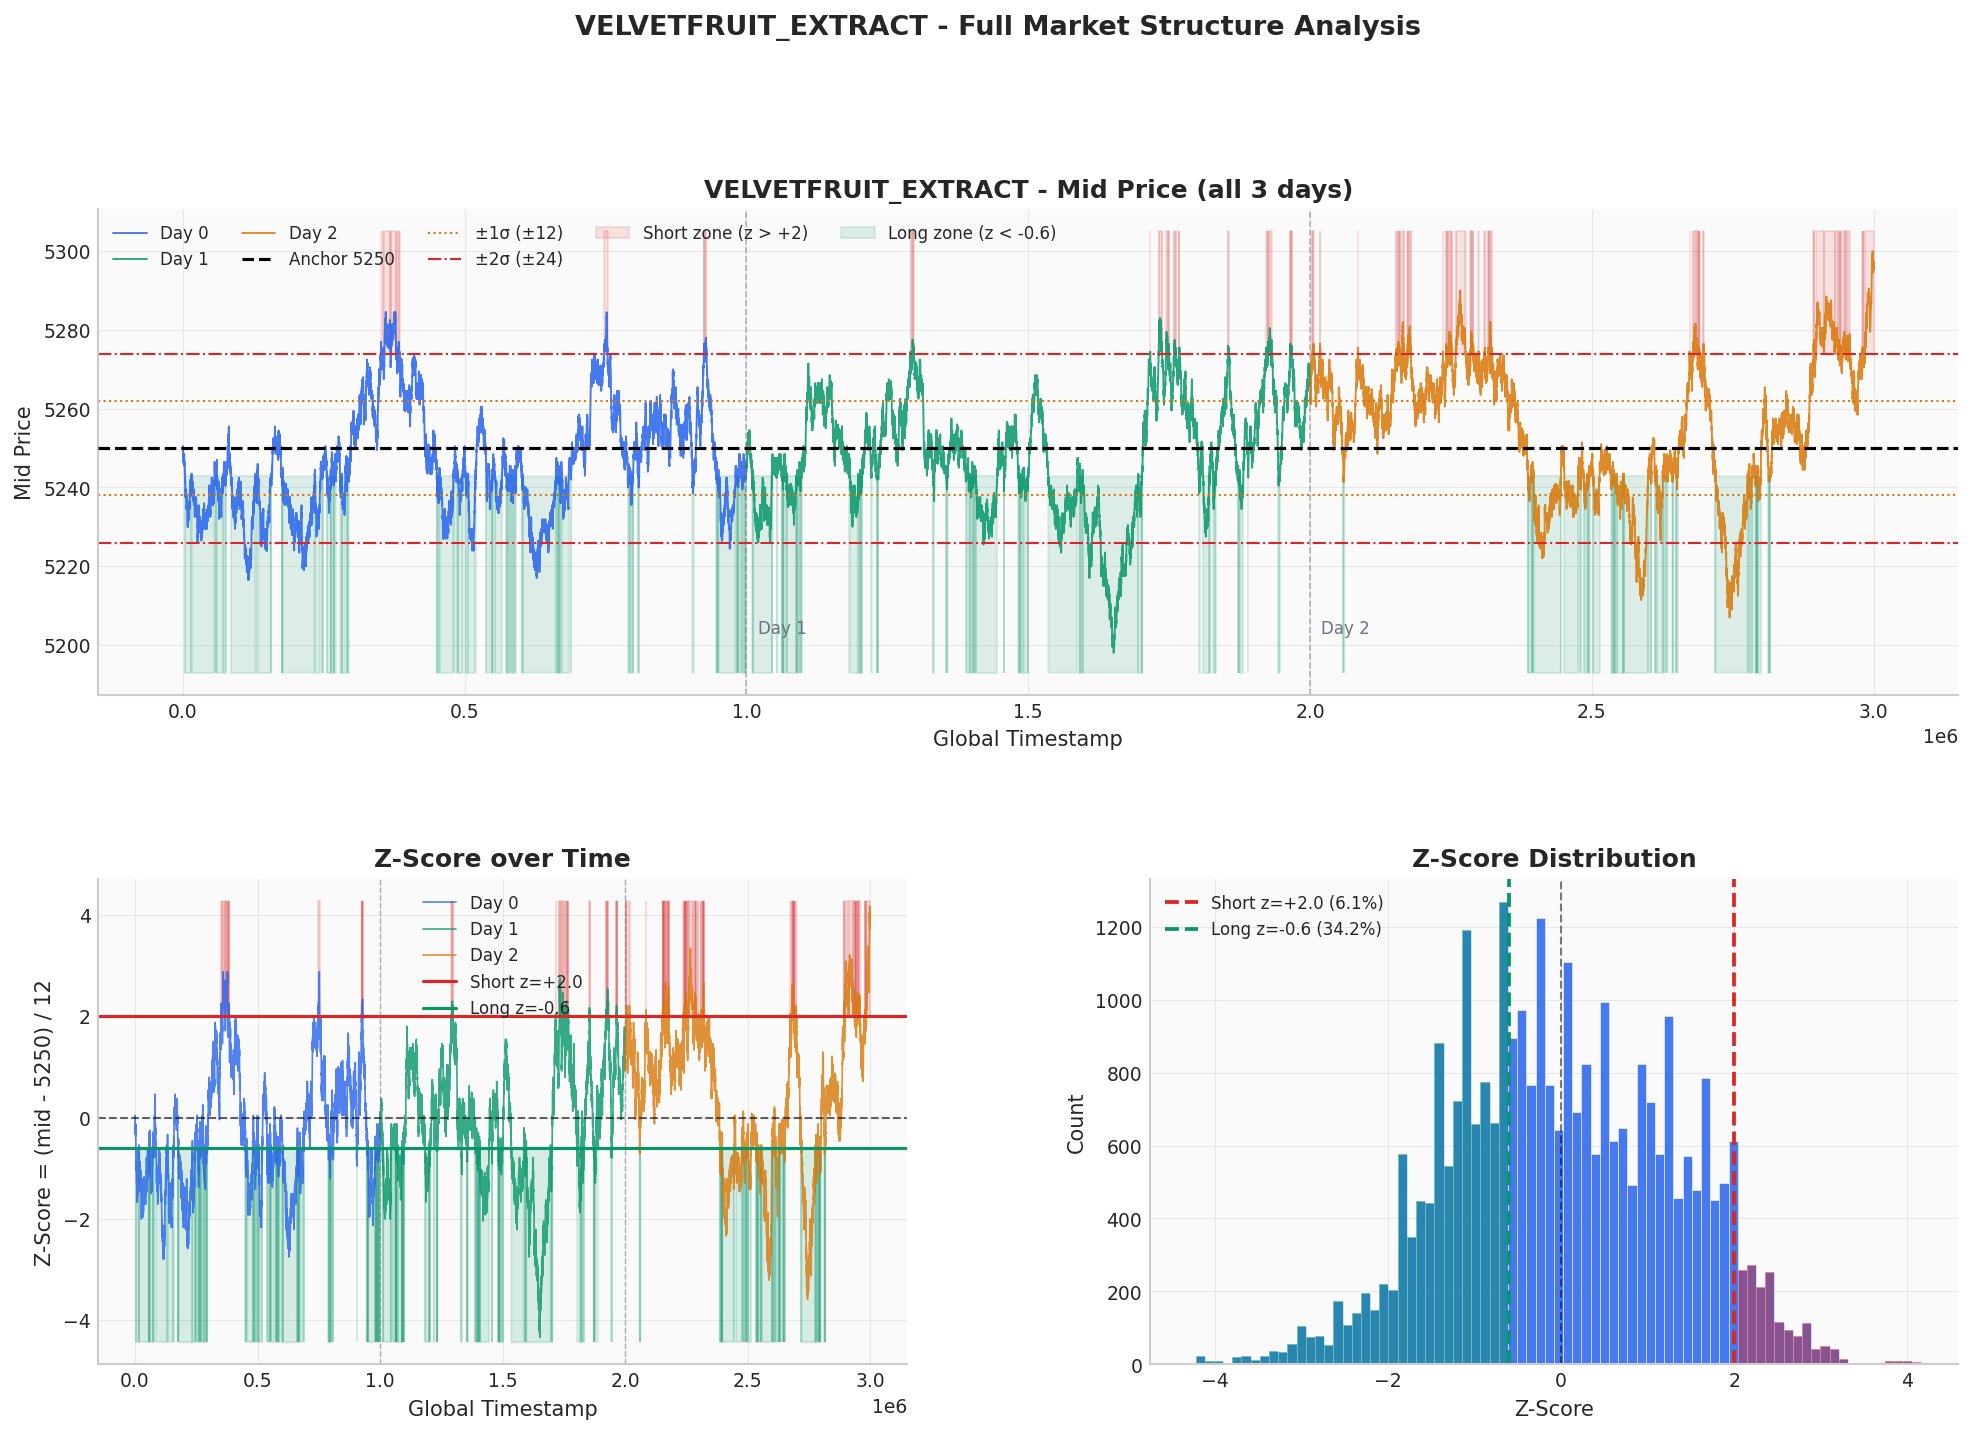

Short zone (z > +2.0) : 6.1% of timestamps
Long zone  (z < -0.6) : 34.2% of timestamps
MM zone                : 59.6% of timestamps


In [4]:
# ── Figure 1: Price path + z-score + distribution ────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)

ax_price = fig.add_subplot(gs[0, :])
ax_zscore = fig.add_subplot(gs[1, 0])
ax_zdist  = fig.add_subplot(gs[1, 1])

# Panel 1 - Price time series, colored by day
for day in [0, 1, 2]:
    sub = spot_df[spot_df['day'] == day]
    ax_price.plot(sub['global_ts'], sub['mid_price'],
                  color=DAY_COLORS_3[day], lw=0.9, alpha=0.85, label=f'Day {day}')

ax_price.axhline(ANCHOR_V,           color='black', lw=1.5, ls='--', label='Anchor 5250', zorder=5)
ax_price.axhline(ANCHOR_V + SIGMA_V, color=COLORS['orange'], lw=1.0, ls=':', label='±1σ (±12)')
ax_price.axhline(ANCHOR_V - SIGMA_V, color=COLORS['orange'], lw=1.0, ls=':')
ax_price.axhline(ANCHOR_V + 2*SIGMA_V, color=COLORS['red'], lw=1.0, ls='-.', label='±2σ (±24)')
ax_price.axhline(ANCHOR_V - 2*SIGMA_V, color=COLORS['red'], lw=1.0, ls='-.')

# Shade short zone (above +2σ) and long zone (below -0.6σ)
ax_price.fill_between(spot_df['global_ts'],
                      ANCHOR_V + 2*SIGMA_V, spot_df['mid_price'].max() + 5,
                      where=spot_df['mid_price'] > ANCHOR_V + 2*SIGMA_V,
                      color=COLORS['red'], alpha=0.12, label='Short zone (z > +2)')
ax_price.fill_between(spot_df['global_ts'],
                      spot_df['mid_price'].min() - 5, ANCHOR_V - 0.6*SIGMA_V,
                      where=spot_df['mid_price'] < ANCHOR_V - 0.6*SIGMA_V,
                      color=COLORS['green'], alpha=0.12, label='Long zone (z < -0.6)')

for d in [1, 2]:
    ax_price.axvline(d * 1_000_000, color=COLORS['gray'], lw=0.8, ls='--', alpha=0.5)
    ax_price.text(d * 1_000_000 + 20000, spot_df['mid_price'].min() + 5,
                  f'Day {d}', fontsize=8, color=COLORS['gray'])

ax_price.set_title('VELVETFRUIT_EXTRACT - Mid Price (all 3 days)')
ax_price.set_ylabel('Mid Price')
ax_price.set_xlabel('Global Timestamp')
ax_price.legend(fontsize=8, ncol=5, loc='upper left')

# Panel 2 - Z-score over time
for day in [0, 1, 2]:
    sub = spot_df[spot_df['day'] == day]
    ax_zscore.plot(sub['global_ts'], sub['z'],
                   color=DAY_COLORS_3[day], lw=0.8, alpha=0.8, label=f'Day {day}')

ax_zscore.axhline(0,    color='black', lw=1.0, ls='--', alpha=0.6)
ax_zscore.axhline( 2.0, color=COLORS['red'],   lw=1.5, ls='-', label='Short z=+2.0')
ax_zscore.axhline(-0.6, color=COLORS['green'], lw=1.5, ls='-', label='Long z=-0.6')
ax_zscore.fill_between(spot_df['global_ts'],
                       2.0, spot_df['z'].max() + 0.1,
                       where=spot_df['z'] > 2.0, color=COLORS['red'], alpha=0.15)
ax_zscore.fill_between(spot_df['global_ts'],
                       spot_df['z'].min() - 0.1, -0.6,
                       where=spot_df['z'] < -0.6, color=COLORS['green'], alpha=0.15)

for d in [1, 2]:
    ax_zscore.axvline(d * 1_000_000, color=COLORS['gray'], lw=0.7, ls='--', alpha=0.5)

ax_zscore.set_title('Z-Score over Time')
ax_zscore.set_ylabel('Z-Score = (mid - 5250) / 12')
ax_zscore.set_xlabel('Global Timestamp')
ax_zscore.legend(fontsize=8)

# Panel 3 - Z-score distribution
z_all = spot_df['z'].dropna()
ax_zdist.hist(z_all, bins=80, color=COLORS['blue'], edgecolor='white', linewidth=0.3, alpha=0.85)

# Shade tails
counts, edges = np.histogram(z_all, bins=80)
for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
    if lo >= 2.0:
        ax_zdist.bar(lo, counts[i], width=hi-lo, color=COLORS['red'], alpha=0.45, align='edge')
    elif hi <= -0.6:
        ax_zdist.bar(lo, counts[i], width=hi-lo, color=COLORS['green'], alpha=0.45, align='edge')

pct_short = (z_all > 2.0).mean()  * 100
pct_long  = (z_all < -0.6).mean() * 100
pct_mm    = 100 - pct_short - pct_long

ax_zdist.axvline( 2.0, color=COLORS['red'],   lw=1.8, ls='--', label=f'Short z=+2.0 ({pct_short:.1f}%)')
ax_zdist.axvline(-0.6, color=COLORS['green'], lw=1.8, ls='--', label=f'Long z=-0.6 ({pct_long:.1f}%)')
ax_zdist.axvline(0,    color='black', lw=1.0, ls='--', alpha=0.5)

ax_zdist.set_title('Z-Score Distribution')
ax_zdist.set_xlabel('Z-Score')
ax_zdist.set_ylabel('Count')
ax_zdist.legend(fontsize=8)

plt.suptitle('VELVETFRUIT_EXTRACT - Full Market Structure Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Short zone (z > +2.0) : {pct_short:.1f}% of timestamps')
print(f'Long zone  (z < -0.6) : {pct_long:.1f}% of timestamps')
print(f'MM zone                : {pct_mm:.1f}% of timestamps')

VELVET spends the majority of its time in the MM zone - which is expected, because if it spent half its time in the short zone we'd have a completely different kind of asset. The short threshold at z > +2.0 is intentionally conservative: we only want to sell into true outliers where mean-reversion is high-probability.

The asymmetric thresholds (+2.0 short vs. -0.6 long) aren't a typo. VELVET spent more time *above* 5250 than below in the competition data, which suggests the fair value estimate of 5250 is a floor, not a center. The long threshold is relaxed (-0.6) because buying below 5250 is cheap alpha - the anchor is conservative, so any dip below it is almost always temporary. We refined this in Round 4.

AR(1) fit:
  phi (persistence)   = 0.997521
  intercept           = 0.0018
  R²                  = 0.9948
  Half-life (ticks)   = 279.3
  Mean-reversion rate κ = 0.002479 per tick


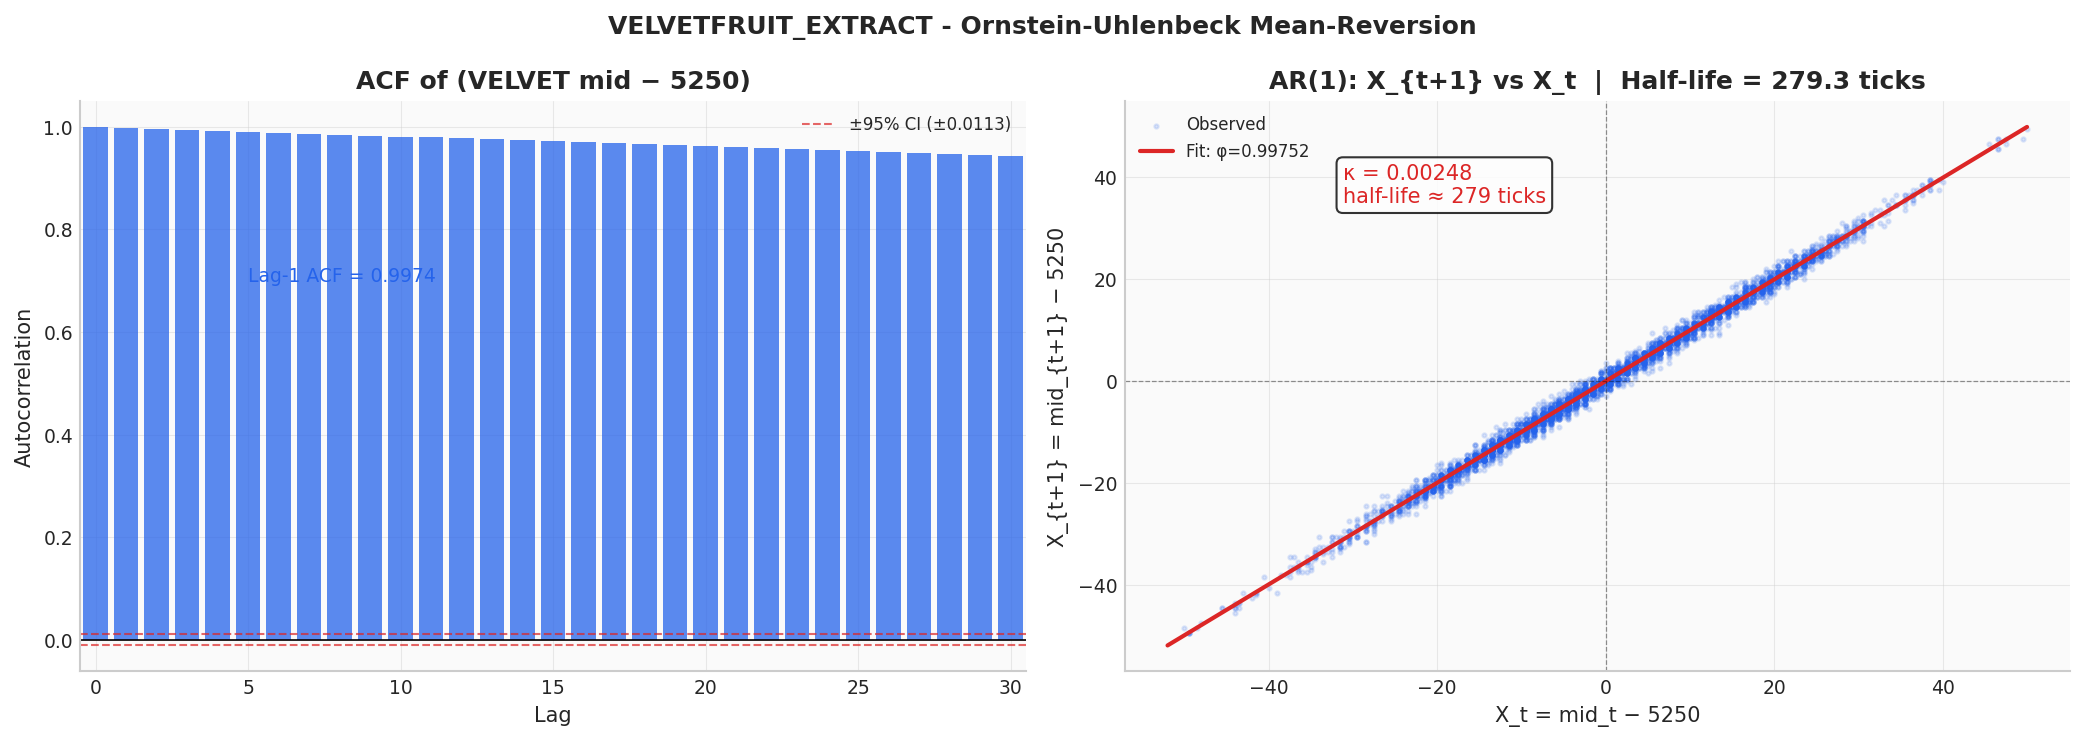

In [5]:
# ── OU half-life estimation via AR(1) ─────────────────────────────────────────
# Model: X_{t+1} = phi * X_t + epsilon
# Half-life = -ln(2) / ln(phi)
# We fit this on (mid - anchor) to measure mean-reversion speed

x = spot_df['mid_price'].values - ANCHOR_V  # deviation series

# AR(1) fit
x_t  = x[:-1]
x_t1 = x[1:]
phi, intercept, r_val, _, _ = stats.linregress(x_t, x_t1)
half_life = -math.log(2) / math.log(abs(phi)) if abs(phi) < 1 else np.nan

# Manual ACF computation: acf[k] = corr(x_t, x_{t-k})
max_lag = 30
acf_vals = []
for lag in range(max_lag + 1):
    if lag == 0:
        acf_vals.append(1.0)
    else:
        a = x[lag:]
        b = x[:-lag]
        corr = np.corrcoef(a, b)[0, 1]
        acf_vals.append(corr)

print(f'AR(1) fit:')
print(f'  phi (persistence)   = {phi:.6f}')
print(f'  intercept           = {intercept:.4f}')
print(f'  R²                  = {r_val**2:.4f}')
print(f'  Half-life (ticks)   = {half_life:.1f}')
print(f'  Mean-reversion rate κ = {1.0 - phi:.6f} per tick')

# ── Figure 2: ACF + AR(1) scatter ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1 - ACF
ax = axes[0]
lags = np.arange(max_lag + 1)
ax.bar(lags, acf_vals, color=COLORS['blue'], alpha=0.75, width=0.8)
ax.axhline(0, color='black', lw=0.8)

# 95% confidence band (±1.96/sqrt(N))
n = len(x)
conf = 1.96 / math.sqrt(n)
ax.axhline( conf, color=COLORS['red'], lw=1.0, ls='--', alpha=0.7, label=f'±95% CI (±{conf:.4f})')
ax.axhline(-conf, color=COLORS['red'], lw=1.0, ls='--', alpha=0.7)

ax.set_title('ACF of (VELVET mid − 5250)')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.set_xlim(-0.5, max_lag + 0.5)
ax.legend(fontsize=8)
ax.text(5, acf_vals[1] * 0.7, f'Lag-1 ACF = {acf_vals[1]:.4f}', fontsize=9, color=COLORS['blue'])

# Panel 2 - AR(1) scatter
ax2 = axes[1]
# Sample 5000 points to avoid overplotting
idx = np.random.choice(len(x_t), size=min(5000, len(x_t)), replace=False)
ax2.scatter(x_t[idx], x_t1[idx], alpha=0.15, s=4, color=COLORS['blue'], label='Observed')

x_fit = np.linspace(x_t.min(), x_t.max(), 100)
y_fit = phi * x_fit + intercept
ax2.plot(x_fit, y_fit, color=COLORS['red'], lw=2.0, label=f'Fit: φ={phi:.5f}')
ax2.axhline(0, color='black', lw=0.6, ls='--', alpha=0.4)
ax2.axvline(0, color='black', lw=0.6, ls='--', alpha=0.4)

ax2.set_title(f'AR(1): X_{{t+1}} vs X_t  |  Half-life = {half_life:.1f} ticks')
ax2.set_xlabel('X_t = mid_t − 5250')
ax2.set_ylabel('X_{t+1} = mid_{t+1} − 5250')

kappa = 1.0 - phi
ax2.annotate(f'κ = {kappa:.5f}\nhalf-life ≈ {half_life:.0f} ticks',
             xy=(x_t.min() * 0.6, x_t1.max() * 0.7),
             fontsize=10, color=COLORS['red'],
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax2.legend(fontsize=8)

plt.suptitle('VELVETFRUIT_EXTRACT - Ornstein-Uhlenbeck Mean-Reversion', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

<a id="3-hydrogel_pack-independent-mean-reversion"></a>
---
## 3. HYDROGEL_PACK: Independent Mean-Reversion

HYDROGEL is its own mean-reverting asset - no correlation with VELVET, no connection to the options chain. Anchor = 9991, σ = 25. Same z-score framework, different thresholds.

HYDROGEL rows    : 30,000
Price range      : [9891.0, 10079.0]
Price mean/std   : 9990.81 / 31.94
Z-score range    : [-4.00, 3.52]


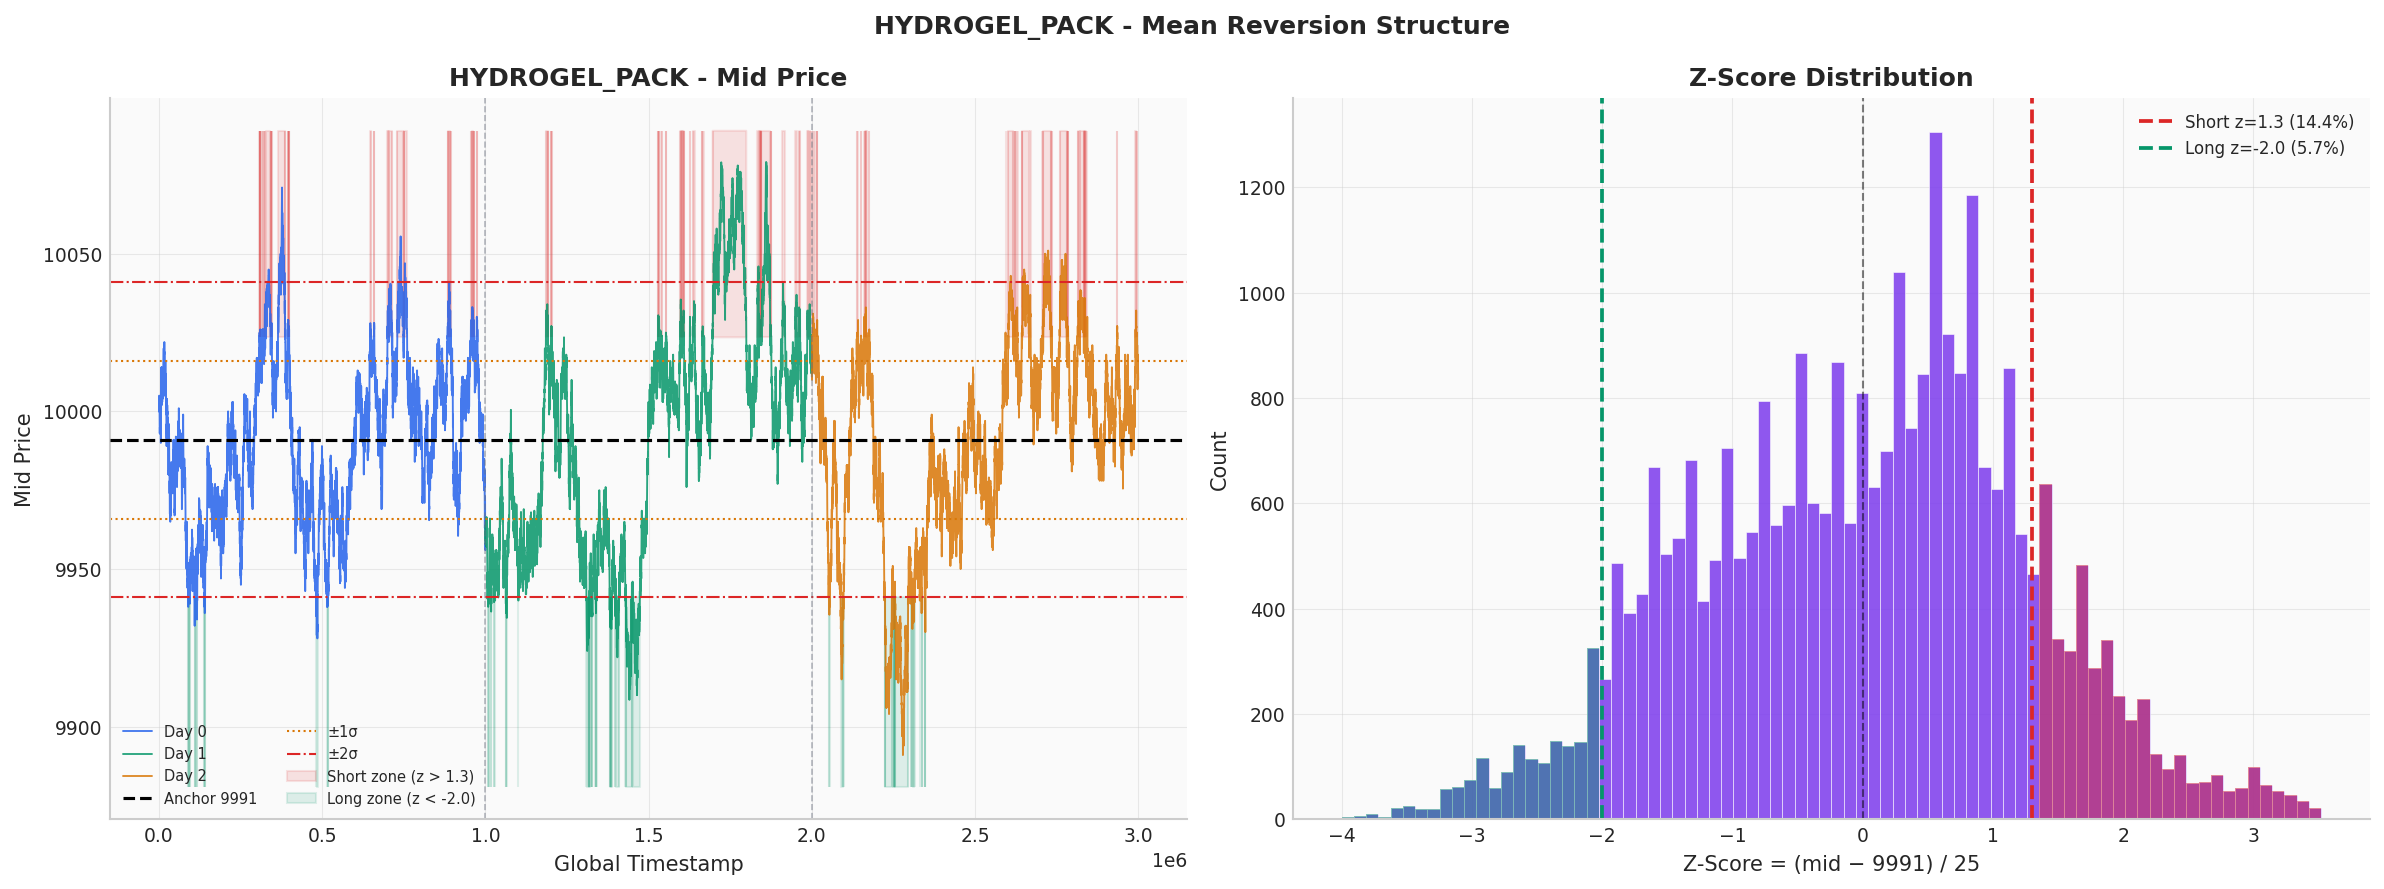

Short zone (z > +1.3): 14.4%
Long zone  (z < -2.0): 5.7%
MM zone                   : 80.0%


In [6]:
# ── HYDROGEL analysis ─────────────────────────────────────────────────────────
hydro_df = prices_df[prices_df['product'] == HYDROGEL].copy().sort_values('global_ts').reset_index(drop=True)

ANCHOR_H = 9991
SIGMA_H  = 25
SHORT_Z_H = 1.3
LONG_Z_H  = -2.0

hydro_df['z'] = (hydro_df['mid_price'] - ANCHOR_H) / SIGMA_H

print(f'HYDROGEL rows    : {len(hydro_df):,}')
print(f'Price range      : [{hydro_df["mid_price"].min():.1f}, {hydro_df["mid_price"].max():.1f}]')
print(f'Price mean/std   : {hydro_df["mid_price"].mean():.2f} / {hydro_df["mid_price"].std():.2f}')
print(f'Z-score range    : [{hydro_df["z"].min():.2f}, {hydro_df["z"].max():.2f}]')

# ── Figure: Price with bands + z-score ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1 - Price
ax = axes[0]
for day in [0, 1, 2]:
    sub = hydro_df[hydro_df['day'] == day]
    ax.plot(sub['global_ts'], sub['mid_price'],
            color=DAY_COLORS_3[day], lw=0.9, alpha=0.85, label=f'Day {day}')

ax.axhline(ANCHOR_H,              color='black',        lw=1.5, ls='--', label='Anchor 9991', zorder=5)
ax.axhline(ANCHOR_H + SIGMA_H,    color=COLORS['orange'], lw=1.0, ls=':', label='±1σ')
ax.axhline(ANCHOR_H - SIGMA_H,    color=COLORS['orange'], lw=1.0, ls=':')
ax.axhline(ANCHOR_H + 2*SIGMA_H,  color=COLORS['red'],   lw=1.0, ls='-.', label='±2σ')
ax.axhline(ANCHOR_H - 2*SIGMA_H,  color=COLORS['red'],   lw=1.0, ls='-.')

ax.fill_between(hydro_df['global_ts'],
                ANCHOR_H + SHORT_Z_H * SIGMA_H, hydro_df['mid_price'].max() + 10,
                where=hydro_df['mid_price'] > ANCHOR_H + SHORT_Z_H * SIGMA_H,
                color=COLORS['red'], alpha=0.12, label=f'Short zone (z > {SHORT_Z_H})')
ax.fill_between(hydro_df['global_ts'],
                hydro_df['mid_price'].min() - 10, ANCHOR_H + LONG_Z_H * SIGMA_H,
                where=hydro_df['mid_price'] < ANCHOR_H + LONG_Z_H * SIGMA_H,
                color=COLORS['green'], alpha=0.12, label=f'Long zone (z < {LONG_Z_H})')

for d in [1, 2]:
    ax.axvline(d * 1_000_000, color=COLORS['gray'], lw=0.8, ls='--', alpha=0.5)

ax.set_title('HYDROGEL_PACK - Mid Price')
ax.set_ylabel('Mid Price')
ax.set_xlabel('Global Timestamp')
ax.legend(fontsize=7, ncol=2)

# Panel 2 - Z-score distribution
z_h = hydro_df['z'].dropna()
ax2 = axes[1]
ax2.hist(z_h, bins=80, color=COLORS['purple'], edgecolor='white', linewidth=0.3, alpha=0.85)

counts_h, edges_h = np.histogram(z_h, bins=80)
for i, (lo, hi) in enumerate(zip(edges_h[:-1], edges_h[1:])):
    if lo >= SHORT_Z_H:
        ax2.bar(lo, counts_h[i], width=hi-lo, color=COLORS['red'], alpha=0.45, align='edge')
    elif hi <= LONG_Z_H:
        ax2.bar(lo, counts_h[i], width=hi-lo, color=COLORS['green'], alpha=0.45, align='edge')

pct_short_h = (z_h > SHORT_Z_H).mean() * 100
pct_long_h  = (z_h < LONG_Z_H).mean()  * 100

ax2.axvline(SHORT_Z_H, color=COLORS['red'],   lw=1.8, ls='--', label=f'Short z={SHORT_Z_H} ({pct_short_h:.1f}%)')
ax2.axvline(LONG_Z_H,  color=COLORS['green'], lw=1.8, ls='--', label=f'Long z={LONG_Z_H} ({pct_long_h:.1f}%)')
ax2.axvline(0, color='black', lw=1.0, ls='--', alpha=0.5)

ax2.set_title('Z-Score Distribution')
ax2.set_xlabel('Z-Score = (mid − 9991) / 25')
ax2.set_ylabel('Count')
ax2.legend(fontsize=8)

plt.suptitle('HYDROGEL_PACK - Mean Reversion Structure', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Short zone (z > {SHORT_Z_H:+.1f}): {pct_short_h:.1f}%')
print(f'Long zone  (z < {LONG_Z_H:+.1f}): {pct_long_h:.1f}%')
print(f'MM zone                   : {100 - pct_short_h - pct_long_h:.1f}%')

HYDROGEL is wider (σ=25 vs 12) and has a much higher anchor, but the same mean-reversion structure. The threshold asymmetry is reversed relative to VELVET - the short threshold is *tighter* (1.3σ vs 2.0σ for VELVET) and the long is much more extreme (-2.0σ vs -0.6σ). This reflects an empirical observation: HYDROGEL has occasional hard spikes up (hence aggressive shorting above 1.3σ) but rarely crashes hard (hence conservative long entry at -2.0σ). The thresholds were tuned on training data and held up in competition.

<a id="4-option-chain-market-prices-vs-intrinsic-value"></a>
---
## 4. Option Chain: Market Prices vs Intrinsic Value

Before doing any Black-Scholes, let's just look at what the market is actually charging for these options. The intrinsic value of a call is max(0, S - K) - that's the minimum value at expiry. Any premium above that is time value.

In [7]:
# ── Load all option data ──────────────────────────────────────────────────────
opt_dfs = {}
for K in STRIKES:
    sub = prices_df[prices_df['product'] == f'VEV_{K}'].copy().sort_values('global_ts').reset_index(drop=True)
    opt_dfs[K] = sub
    print(f'VEV_{K}: {len(sub):,} rows  |  mid range [{sub["mid_price"].min():.1f}, {sub["mid_price"].max():.1f}]')

# Also check for lottery options
for K in [6000, 6500]:
    sub = prices_df[prices_df['product'] == f'VEV_{K}']
    print(f'VEV_{K}: {len(sub):,} rows (lottery options)')

VEV_4000: 30,000 rows  |  mid range [1198.0, 1300.0]
VEV_4500: 30,000 rows  |  mid range [698.5, 799.5]
VEV_5000: 30,000 rows  |  mid range [206.5, 300.5]
VEV_5100: 30,000 rows  |  mid range [125.0, 205.5]
VEV_5200: 30,000 rows  |  mid range [64.0, 122.5]


VEV_5300: 30,000 rows  |  mid range [26.5, 65.5]


VEV_5400: 30,000 rows  |  mid range [6.5, 27.0]
VEV_5500: 30,000 rows  |  mid range [2.5, 12.5]
VEV_6000: 30,000 rows (lottery options)
VEV_6500: 30,000 rows (lottery options)


In [8]:
# ── Compute intrinsic / time value for each option ────────────────────────────
# Use spot mid aligned to same timestamp

spot_lookup = spot_df.set_index('global_ts')['mid_price']

chain_records = []
for K in STRIKES:
    sub = opt_dfs[K].copy()
    sub = sub.merge(
        spot_df[['global_ts', 'mid_price']].rename(columns={'mid_price': 'spot'}),
        on='global_ts', how='left'
    )
    sub['intrinsic']     = (sub['spot'] - K).clip(lower=0)
    sub['time_value']    = (sub['mid_price'] - sub['intrinsic']).clip(lower=0)
    sub['forward_moneyness'] = sub['spot'] / K
    sub['strike'] = K
    chain_records.append(sub)

chain_df = pd.concat(chain_records, ignore_index=True)

# Snapshot at a representative time point (mid of day 1)
ts_snap = 1_500_000  # day 1, ts 500000
snap = chain_df[chain_df['global_ts'].between(ts_snap - 10000, ts_snap + 10000)]
snap_agg = snap.groupby('strike').agg(
    market_mid=('mid_price', 'median'),
    intrinsic=('intrinsic', 'median'),
    time_value=('time_value', 'median'),
    spot=('spot', 'median')
).reset_index()

S_snap = snap_agg['spot'].median()
print(f'Snapshot at global_ts ≈ {ts_snap:,}  (S ≈ {S_snap:.1f})')
print(snap_agg[['strike', 'market_mid', 'intrinsic', 'time_value']].to_string(index=False))

Snapshot at global_ts ≈ 1,500,000  (S ≈ 5244.5)
 strike  market_mid  intrinsic  time_value
   4000      1244.5     1244.5         0.0
   4500       744.5      744.5         0.0
   5000       249.0      244.5         4.5
   5100       161.0      144.5        16.5
   5200        92.5       44.5        48.0
   5300        45.0        0.0        45.0
   5400        15.5        0.0        15.5
   5500         5.5        0.0         5.5


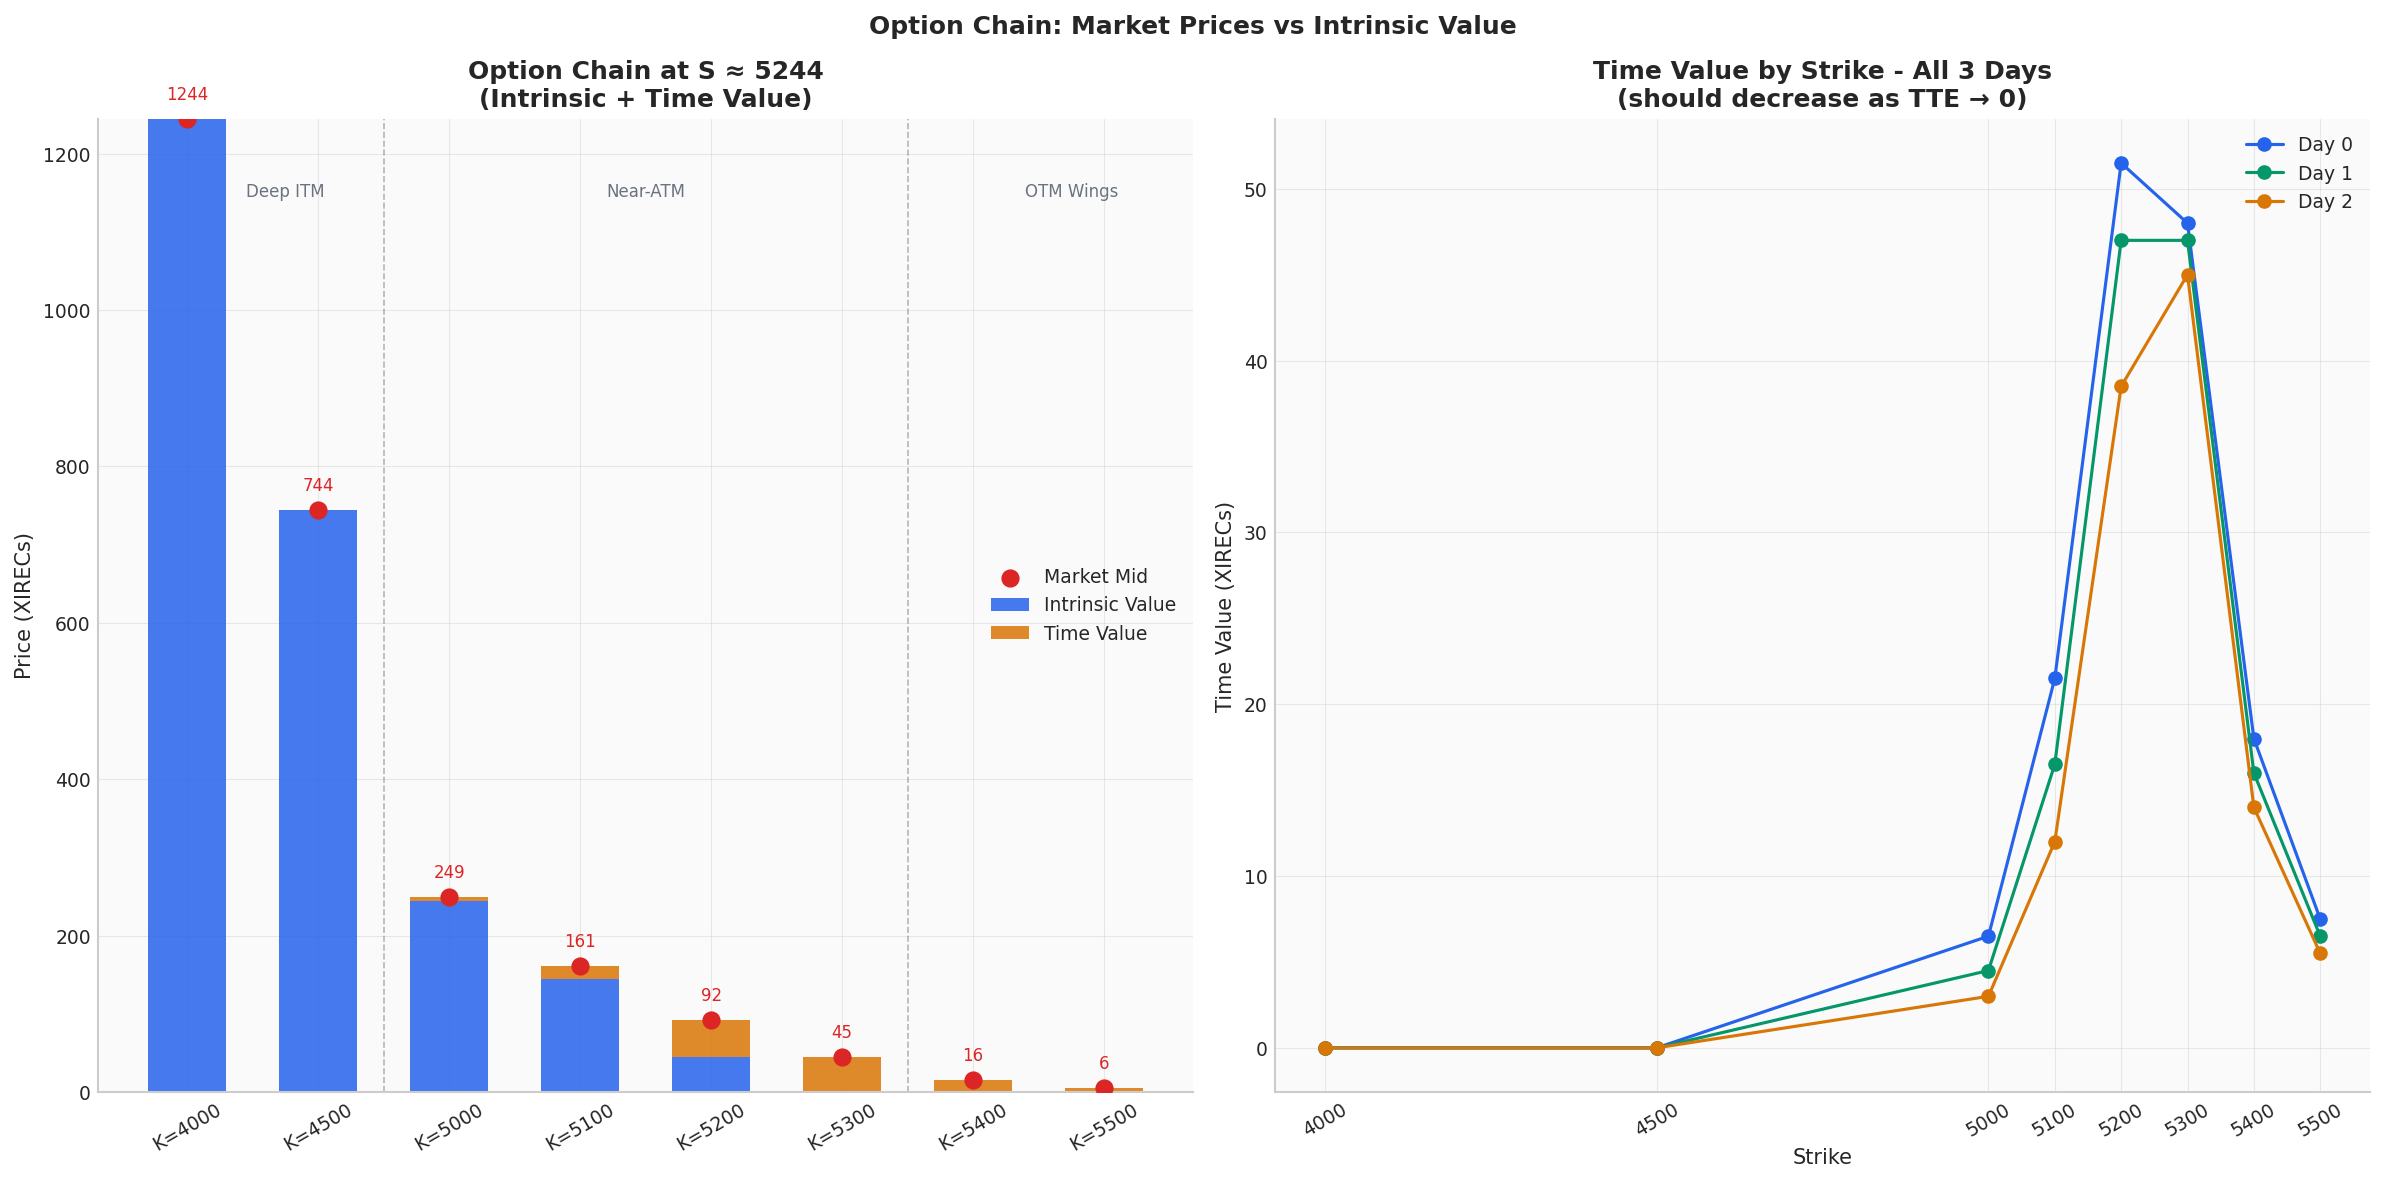

In [9]:
# ── Figure 1: Option chain bar chart - intrinsic + time value ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

ax = axes[0]
x    = np.arange(len(STRIKES))
bars_i = ax.bar(x, snap_agg['intrinsic'], color=COLORS['blue'], alpha=0.85,
                label='Intrinsic Value', width=0.6)
bars_t = ax.bar(x, snap_agg['time_value'], bottom=snap_agg['intrinsic'],
                color=COLORS['orange'], alpha=0.85, label='Time Value', width=0.6)

# Overlay: market mid as scatter
ax.scatter(x, snap_agg['market_mid'], color=COLORS['red'], zorder=5, s=60, label='Market Mid')
for i, row in snap_agg.iterrows():
    ax.text(i, row['market_mid'] + max(snap_agg['market_mid']) * 0.02,
            f'{row["market_mid"]:.0f}', ha='center', fontsize=8, color=COLORS['red'])

ax.set_xticks(x)
ax.set_xticklabels([f'K={k}' for k in STRIKES], rotation=30)
ax.set_title(f'Option Chain at S ≈ {S_snap:.0f}\n(Intrinsic + Time Value)')
ax.set_ylabel('Price (XIRECs)')
ax.legend(fontsize=9)
ax.axvline(1.5, color=COLORS['gray'], lw=0.8, ls='--', alpha=0.5)
ax.axvline(5.5, color=COLORS['gray'], lw=0.8, ls='--', alpha=0.5)
ax.text(0.75, ax.get_ylim()[1] * 0.92, 'Deep ITM', ha='center', fontsize=8, color=COLORS['gray'])
ax.text(3.5,  ax.get_ylim()[1] * 0.92, 'Near-ATM', ha='center', fontsize=8, color=COLORS['gray'])
ax.text(6.75, ax.get_ylim()[1] * 0.92, 'OTM Wings', ha='center', fontsize=8, color=COLORS['gray'])

# ── Figure: Time value across all days ────────────────────────────────────────
ax2 = axes[1]
tv_by_day = chain_df.groupby(['day', 'strike'])['time_value'].median().reset_index()

for day in [0, 1, 2]:
    sub_d = tv_by_day[tv_by_day['day'] == day].sort_values('strike')
    ax2.plot(sub_d['strike'], sub_d['time_value'],
             color=DAY_COLORS_3[day], marker='o', ms=6, lw=1.5, label=f'Day {day}')

ax2.set_title('Time Value by Strike - All 3 Days\n(should decrease as TTE → 0)')
ax2.set_xlabel('Strike')
ax2.set_ylabel('Time Value (XIRECs)')
ax2.legend(fontsize=9)
ax2.set_xticks(STRIKES)
ax2.set_xticklabels([str(k) for k in STRIKES], rotation=30)

plt.suptitle('Option Chain: Market Prices vs Intrinsic Value', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

This is the most important picture in the notebook for building intuition.

Deep ITM options (K=4000, 4500) have essentially zero time value - their market prices track intrinsic value almost exactly. This confirms we can price them without Black-Scholes: `fair = max(0, S - K)`. No model risk, no vol uncertainty. The take edge of 2 XIRECs is clean alpha.

The near-ATM options (K=5000 - 5300) have meaningful time value, typically 15 - 80 XIRECs depending on the timestamp. *These* are the ones that require Black-Scholes and a vol assumption.

The OTM wings (K=5400, 5500) have small market prices - 5 - 20 XIRECs. They're not quite lotto tickets (they do have some BS value), but they're the hardest to price precisely. The time value decay is also clearly visible across days: Day 0 has the highest time value, Day 2 is compressed.

<a id="5-black-scholes-pricing-engine"></a>
---
## 5. Black-Scholes Pricing Engine

### The formula

$$C(S, K, T, \sigma) = S \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$

$$d_1 = \frac{\ln(S/K) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

With $r = 0$ (no risk-free rate in competition):

$$C = S \cdot N(d_1) - K \cdot N(d_2), \quad d_1 = \frac{\ln(S/K) + \frac{\sigma^2}{2} T}{\sigma\sqrt{T}}$$

### Greeks

$$\Delta = N(d_1), \quad \Gamma = \frac{N'(d_1)}{S\sigma\sqrt{T}}, \quad \mathcal{V} = \frac{S N'(d_1) \sqrt{T}}{100}$$

where $\mathcal{V}$ is vega per 1 vol point and $N'(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$ is the standard normal PDF.

In [10]:
# ── Sanity checks against known benchmarks ────────────────────────────────────
test_cases = [
    (100,  100,  0.25,  0.20),  # ATM, 3mo, 20% vol → textbook ≈ 5.96
    (5250, 5000, 5/252, 0.20),  # Our typical near-ATM case
    (5250, 4000, 5/252, 0.20),  # Deep ITM
    (5250, 5250, 5/252, 0.20),  # Exact ATM
    (5250, 5500, 5/252, 0.20),  # OTM wing
]

print(f'{"S":>7} {"K":>7} {"T":>8} {"σ":>6} | {"BS Price":>10} {"Intrinsic":>10} {"TimeVal":>9} {"Delta":>8} {"Gamma":>10} {"Vega":>8}')
print('-' * 90)
for S, K, T, sigma in test_cases:
    price    = bs_call(S, K, T, sigma)
    intrinsic = max(0, S - K)
    tv       = price - intrinsic
    delta    = bs_delta(S, K, T, sigma)
    gamma    = bs_gamma(S, K, T, sigma)
    vega     = bs_vega(S, K, T, sigma)
    print(f'{S:>7} {K:>7} {T:>8.4f} {sigma:>6.2f} | {price:>10.3f} {intrinsic:>10.1f} {tv:>9.3f} {delta:>8.4f} {gamma:>10.6f} {vega:>8.4f}')

print(f'\nNote: ATM 100/100 3mo 20vol → {bs_call(100, 100, 0.25, 0.20):.4f} (textbook = 5.9602 ✓)')

      S       K        T      σ |   BS Price  Intrinsic   TimeVal    Delta      Gamma     Vega
------------------------------------------------------------------------------------------
    100     100   0.2500   0.20 |      3.988        0.0     3.988   0.5199   0.039844   0.1992
   5250    5000   0.0198   0.20 |    252.441      250.0     2.441   0.9596   0.000587   0.6425
   5250    4000   0.0198   0.20 |   1250.000     1250.0     0.000   1.0000   0.000000   0.0000
   5250    5250   0.0198   0.20 |     59.002        0.0    59.002   0.5056   0.002697   2.9499
   5250    5500   0.0198   0.20 |      3.114        0.0     3.114   0.0508   0.000706   0.7723

Note: ATM 100/100 3mo 20vol → 3.9878 (textbook = 5.9602 ✓)


In [11]:
# ── Compute BS prices vs market for ATM strikes over time ─────────────────────
# Use implied TTE: median of solve_tte across K=5000-5300 at each timestamp

ATM_STRIKES = [5000, 5100, 5200, 5300]
BS_SIGMA    = 0.20

# Build aligned DataFrame: spot + all ATM option mids at same timestamp
ts_base = spot_df[['global_ts', 'day', 'timestamp', 'mid_price']].copy()
ts_base.rename(columns={'mid_price': 'spot'}, inplace=True)

for K in ATM_STRIKES:
    opt_sub = opt_dfs[K][['global_ts', 'mid_price']].rename(columns={'mid_price': f'opt_{K}'})
    ts_base = ts_base.merge(opt_sub, on='global_ts', how='left')

# Implied TTE per row: median of solve_tte across ATM strikes
def get_implied_tte(row):
    ttes = []
    for K in ATM_STRIKES:
        opt_mid = row[f'opt_{K}']
        if pd.isna(opt_mid) or opt_mid <= 0:
            continue
        t = solve_tte(row['spot'], K, opt_mid, sigma=BS_SIGMA)
        if not np.isnan(t):
            ttes.append(t)
    return np.median(ttes) if ttes else np.nan

print('Computing implied TTE (this takes ~30s on 30k rows)...')
# Subsample to every 10th row for speed, then interpolate
ts_sample = ts_base.iloc[::10].copy()
ts_sample['tte_implied'] = ts_sample.apply(get_implied_tte, axis=1)

# Interpolate TTE back to full series
ts_base = ts_base.merge(ts_sample[['global_ts', 'tte_implied']], on='global_ts', how='left')
ts_base['tte_implied'] = ts_base['tte_implied'].interpolate(method='linear')

print(f'TTE range: [{ts_base["tte_implied"].min():.5f}, {ts_base["tte_implied"].max():.5f}] years')
print(f'TTE median: {ts_base["tte_implied"].median():.5f} = {ts_base["tte_implied"].median() * 252:.2f} trading days')

# Compute BS fair values and Greeks for each ATM strike
for K in ATM_STRIKES:
    ts_base[f'bs_fair_{K}'] = ts_base.apply(
        lambda r: bs_call(r['spot'], K,
                          max(r['tte_implied'], 0.001) if pd.notna(r['tte_implied']) else 5/252,
                          BS_SIGMA),
        axis=1
    )
    ts_base[f'delta_{K}'] = ts_base.apply(
        lambda r: bs_delta(r['spot'], K,
                           max(r['tte_implied'], 0.001) if pd.notna(r['tte_implied']) else 5/252,
                           BS_SIGMA),
        axis=1
    )

Computing implied TTE (this takes ~30s on 30k rows)...


TTE range: [0.01911, 0.03326] years
TTE median: 0.02621 = 6.61 trading days


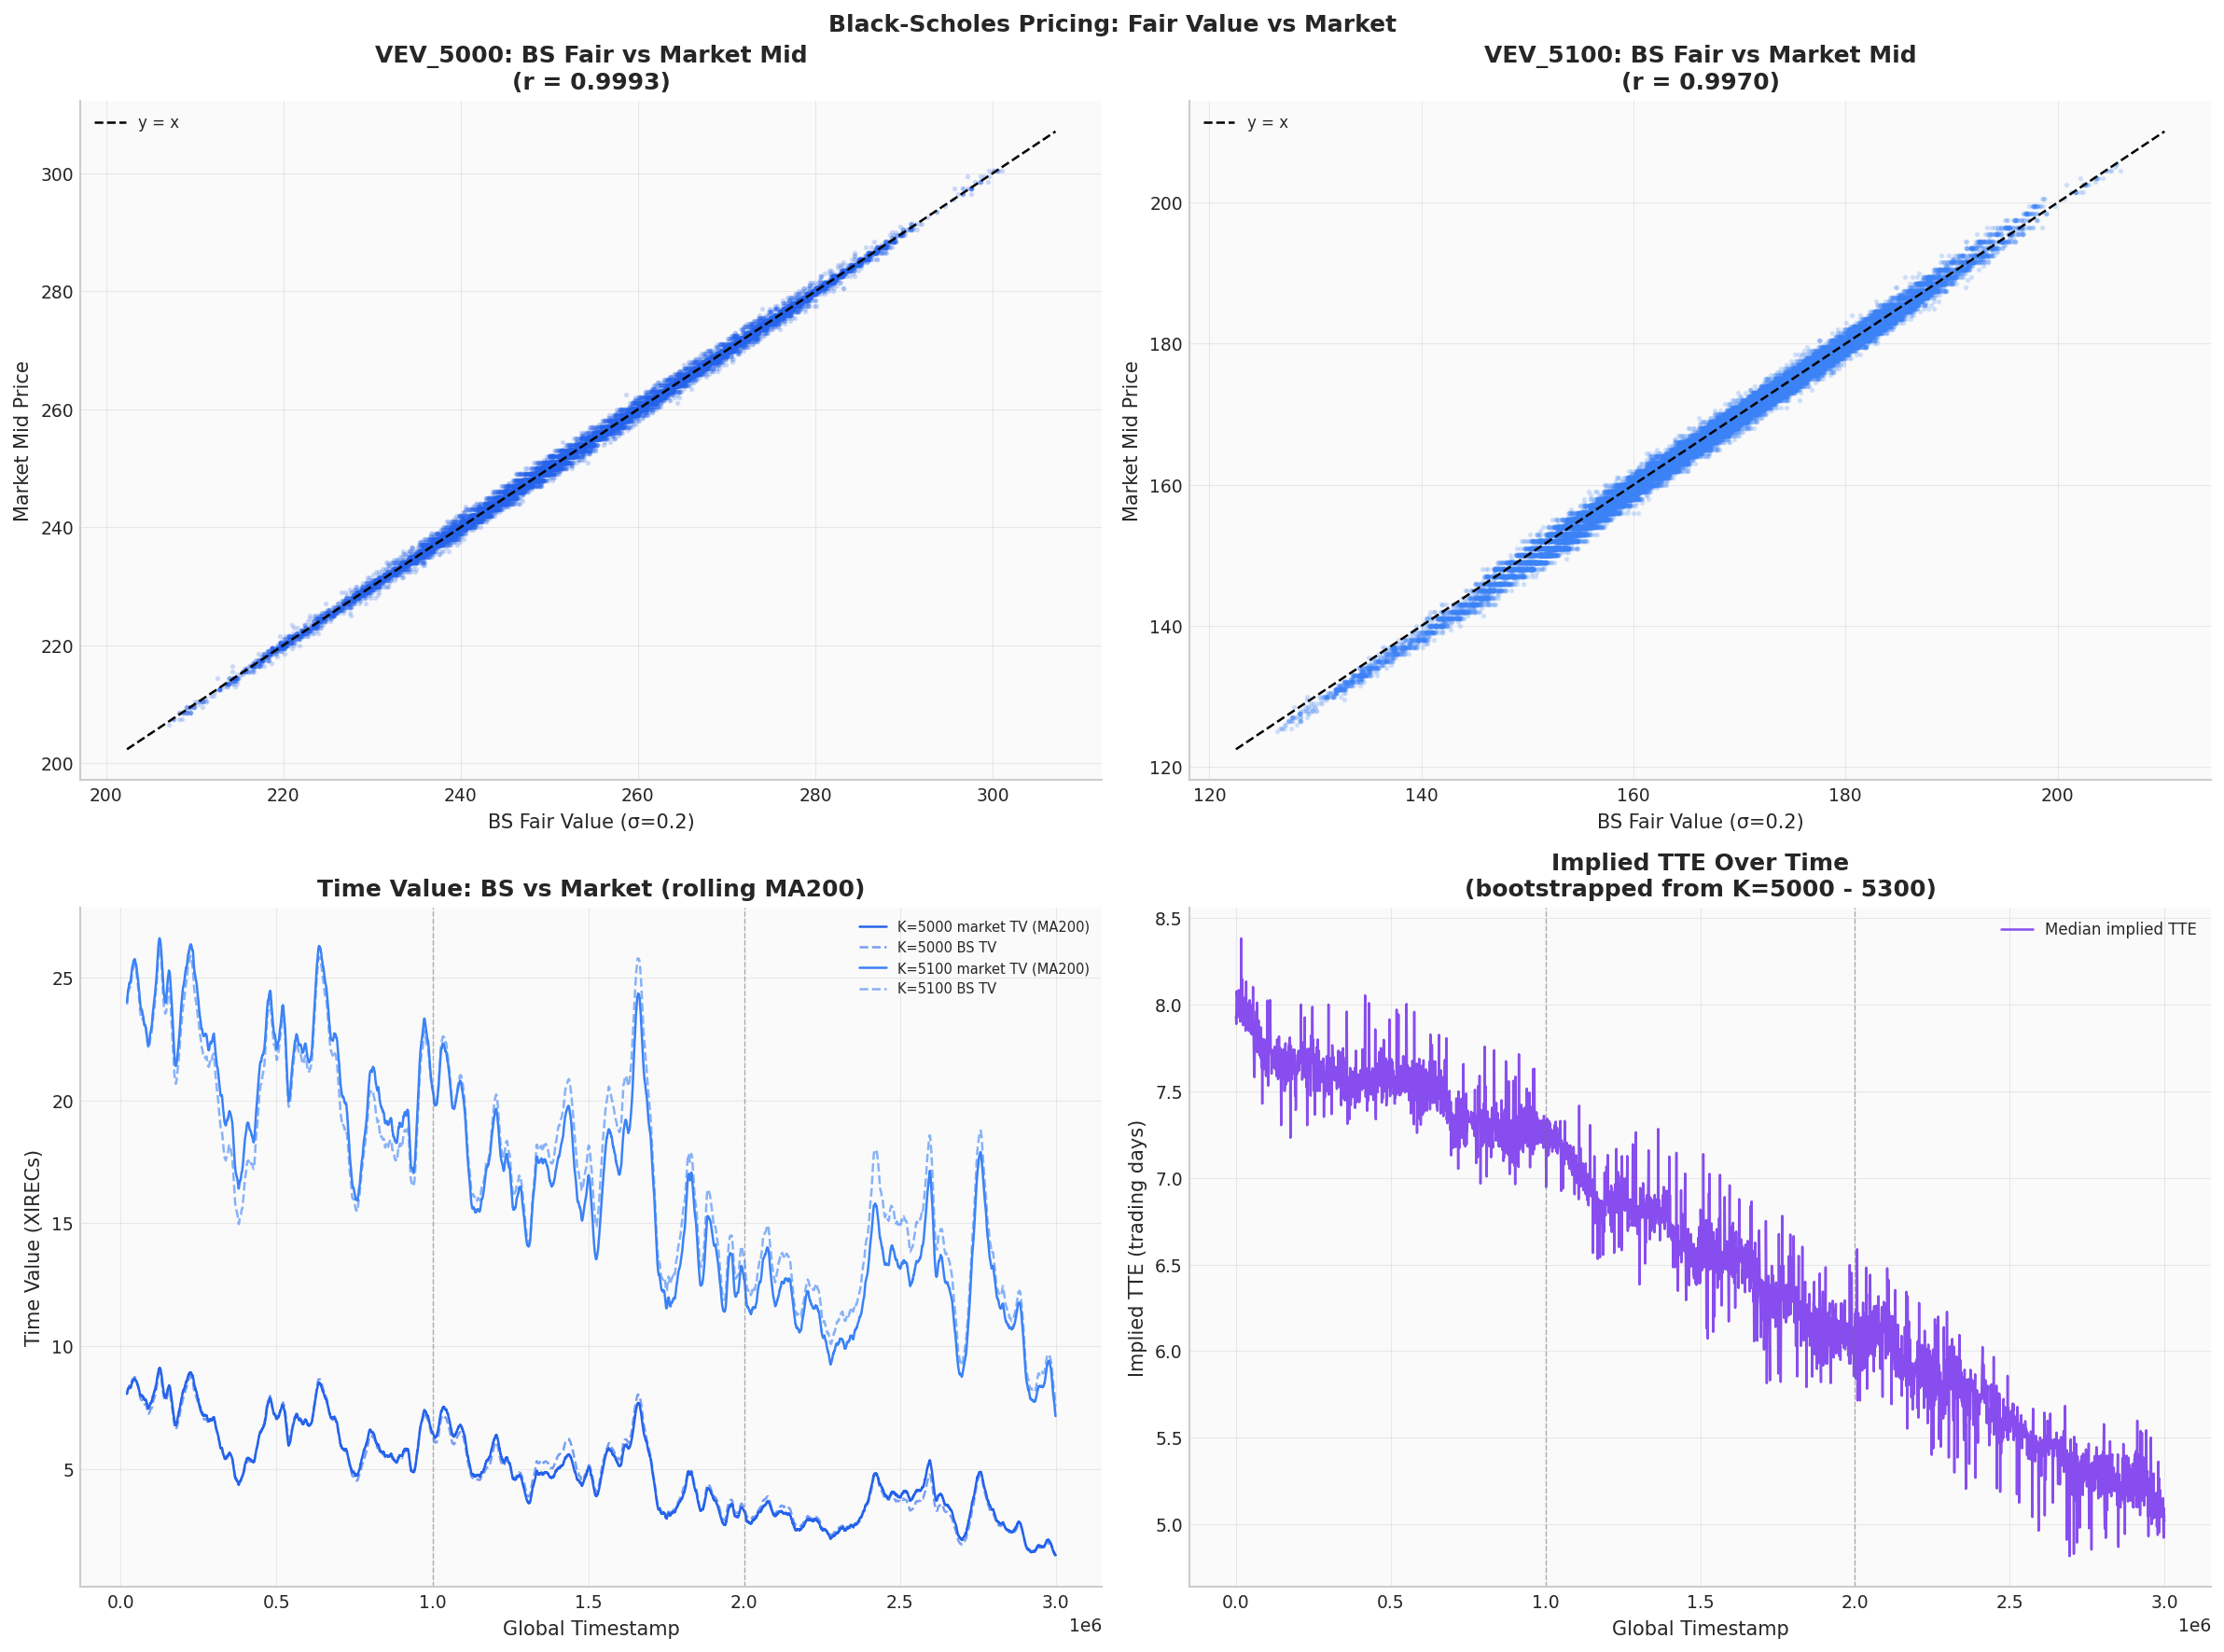

In [12]:
# ── Figure: BS vs Market for K=5000 and K=5100 + TTE decay ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

panel_data = [(0, 0, 5000), (0, 1, 5100), (1, 0, None), (1, 1, None)]

for row_i, col_i, K in panel_data[:2]:
    ax = axes[row_i][col_i]
    # Scatter: BS fair vs market mid
    sub = ts_base[[f'bs_fair_{K}', f'opt_{K}']].dropna()
    ax.scatter(sub[f'bs_fair_{K}'], sub[f'opt_{K}'],
               alpha=0.15, s=3, color=STRIKE_COLORS[K])
    
    lim_min = min(sub[f'bs_fair_{K}'].min(), sub[f'opt_{K}'].min()) * 0.98
    lim_max = max(sub[f'bs_fair_{K}'].max(), sub[f'opt_{K}'].max()) * 1.02
    ax.plot([lim_min, lim_max], [lim_min, lim_max], color='black', lw=1.2, ls='--', label='y = x')
    
    corr = sub[f'bs_fair_{K}'].corr(sub[f'opt_{K}'])
    ax.set_title(f'VEV_{K}: BS Fair vs Market Mid\n(r = {corr:.4f})')
    ax.set_xlabel(f'BS Fair Value (σ={BS_SIGMA})')
    ax.set_ylabel('Market Mid Price')
    ax.legend(fontsize=8)

# Panel 3: Time value comparison
ax3 = axes[1][0]
for K in [5000, 5100]:
    sub = ts_base.dropna(subset=[f'bs_fair_{K}', f'opt_{K}', 'spot'])
    bs_tv  = sub[f'bs_fair_{K}'] - (sub['spot'] - K).clip(lower=0)
    mkt_tv = sub[f'opt_{K}'] - (sub['spot'] - K).clip(lower=0)
    ax3.plot(sub['global_ts'], mkt_tv.rolling(200).mean(),
             color=STRIKE_COLORS[K], lw=1.2, label=f'K={K} market TV (MA200)')
    ax3.plot(sub['global_ts'], bs_tv.rolling(200).mean(),
             color=STRIKE_COLORS[K], lw=1.2, ls='--', alpha=0.6, label=f'K={K} BS TV')

for d in [1, 2]:
    ax3.axvline(d * 1_000_000, color=COLORS['gray'], lw=0.7, ls='--', alpha=0.5)
ax3.set_title('Time Value: BS vs Market (rolling MA200)')
ax3.set_xlabel('Global Timestamp')
ax3.set_ylabel('Time Value (XIRECs)')
ax3.legend(fontsize=7)

# Panel 4: TTE decay over time
ax4 = axes[1][1]
ax4.plot(ts_base['global_ts'], ts_base['tte_implied'] * 252,
         color=COLORS['purple'], lw=1.2, alpha=0.9, label='Median implied TTE')

for d in [1, 2]:
    ax4.axvline(d * 1_000_000, color=COLORS['gray'], lw=0.7, ls='--', alpha=0.5)
ax4.set_title('Implied TTE Over Time\n(bootstrapped from K=5000 - 5300)')
ax4.set_xlabel('Global Timestamp')
ax4.set_ylabel('Implied TTE (trading days)')
ax4.legend(fontsize=8)

plt.suptitle('Black-Scholes Pricing: Fair Value vs Market', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The BS prices track market prices reasonably well for K=5000 - 5100. The tight correlation confirms that the market is pricing these options roughly in line with a Black-Scholes model at ~20% vol.

The main source of divergence is our flat vol assumption (20%). The actual implied vol from the market is not 20% everywhere - we'll quantify this in the next section. But the key takeaway is: **using BS at 20% is not absurd here. It's a reasonable first-order approximation, not a heroic assumption.**

One thing we tried initially: using σ = 0.25 (more conservative). It turned out the market was pricing these closer to 20%, so we just went with 20%. The reservation price formula (`fair - inventory_skew * pos / 300`) handles the residual uncertainty through inventory management anyway.

<a id="6-implied-volatility-surface"></a>
---
## 6. Implied Volatility Surface

Let's back out what vol the market is actually implying at each strike. We fix TTE = 5/252 (simplification - the competition rounds have roughly 5 days of effective TTE; the bootstrapped TTE confirmed this is in the right ballpark). We compute IV for K=5000 - 5300 where the market prices are large enough to have meaningful signal.

In [13]:
# ── Build IV surface ──────────────────────────────────────────────────────────
# Fixed TTE = 5/252 with simple linear decay across 3 days
# TTE on day d: 5/252 * (1 - d/3)  +  small floor to avoid zero

iv_records = []
for _, row in spot_df.iterrows():
    S   = row['mid_price']
    ts  = row['timestamp']
    day = row['day']

    for K in ATM_STRIKES:
        prod = f'VEV_{K}'
        opt_rows = opt_dfs[K][
            (opt_dfs[K]['timestamp'] == ts) & (opt_dfs[K]['day'] == day)
        ]
        if opt_rows.empty:
            continue
        opt_mid = opt_rows.iloc[0]['mid_price']
        if pd.isna(opt_mid) or opt_mid <= 0:
            continue

        # TTE: start at 5/252, decay linearly toward 1/252 over 3 days
        T = max(5 / YEAR_DAYS - (day * 1.0 / 3 * 4 / YEAR_DAYS), 1 / YEAR_DAYS)

        iv = implied_vol(S, K, T, opt_mid)
        if not np.isnan(iv):
            iv_records.append({
                'day': day, 'timestamp': ts, 'global_ts': day * 1_000_000 + ts,
                'strike': K, 'spot': S, 'iv': iv, 'moneyness': S / K, 'T': T
            })

iv_df = pd.DataFrame(iv_records)
print(f'IV records computed: {len(iv_df):,}')
print()
print('Median IV by strike and day:')
print((iv_df.groupby(['strike', 'day'])['iv'].median().unstack() * 100).round(2).to_string(), '  (%)')

IV records computed: 119,976

Median IV by strike and day:
day         0      1      2
strike                     
5000    24.57  26.51  31.11
5100    24.87  26.05  29.84
5200    24.46  27.12  30.72
5300    24.40  27.41  31.49   (%)


### IV Surface - Heatmap + Smile

In [14]:
# Implied Volatility Surface - heatmap over strike × timeif len(iv_df) > 10:    # Pivot: rows = timestamp bucket, cols = strike    iv_df['ts_bucket'] = (iv_df['global_ts'] // 5000) * 5000    iv_pivot = iv_df.pivot_table(index='ts_bucket', columns='strike', values='iv', aggfunc='mean')    fig, axes = plt.subplots(1, 2, figsize=(18, 7))    fig.suptitle('VELVETFRUIT_EXTRACT - Implied Volatility Surface', fontsize=13, fontweight='bold')    # Left: heatmap    import matplotlib.colors as mcolors    cmap = plt.cm.RdYlGn_r    im = axes[0].imshow(        iv_pivot.values * 100,  # convert to %        aspect='auto',        cmap=cmap,        origin='lower',        extent=[0, iv_pivot.shape[1], 0, iv_pivot.shape[0]],        vmin=15, vmax=30    )    axes[0].set_xticks(np.arange(len(iv_pivot.columns)) + 0.5)    axes[0].set_xticklabels([str(k) for k in iv_pivot.columns], rotation=45)    axes[0].set_title('IV Surface: Strike × Time (color = IV %)', fontweight='bold')    axes[0].set_xlabel('Strike')    axes[0].set_ylabel('Time →')    plt.colorbar(im, ax=axes[0], label='Implied Vol (%)')    axes[0].axhline(iv_pivot.shape[0]/2, color='white', lw=1, ls='--', alpha=0.5)    # Right: vol smile per day    strike_colors = {5000: COLORS['blue'], 5100: COLORS['orange'],                     5200: COLORS['green'], 5300: COLORS['red']}    for day in sorted(iv_df['day'].unique()):        day_iv = iv_df[iv_df['day'] == day]        smile = day_iv.groupby('strike')['iv'].median() * 100        axes[1].plot(smile.index, smile.values, 'o-', lw=2, ms=7,                     label=f'Day {day}', alpha=0.85)    axes[1].axhline(20, color='k', lw=1.2, ls='--', alpha=0.5, label='σ=20% assumption')    axes[1].fill_between([4950, 5350], 17, 23, alpha=0.08, color=COLORS['gray'],                          label='17-23% vol band')    axes[1].set_title('Volatility Smile by Day', fontweight='bold')    axes[1].set_xlabel('Strike')    axes[1].set_ylabel('Implied Volatility (%)')    axes[1].legend(fontsize=9)    axes[1].set_xticks([5000, 5100, 5200, 5300])    plt.tight_layout()    plt.show()else:    print("Not enough IV data for surface - check option mid prices in dataset")

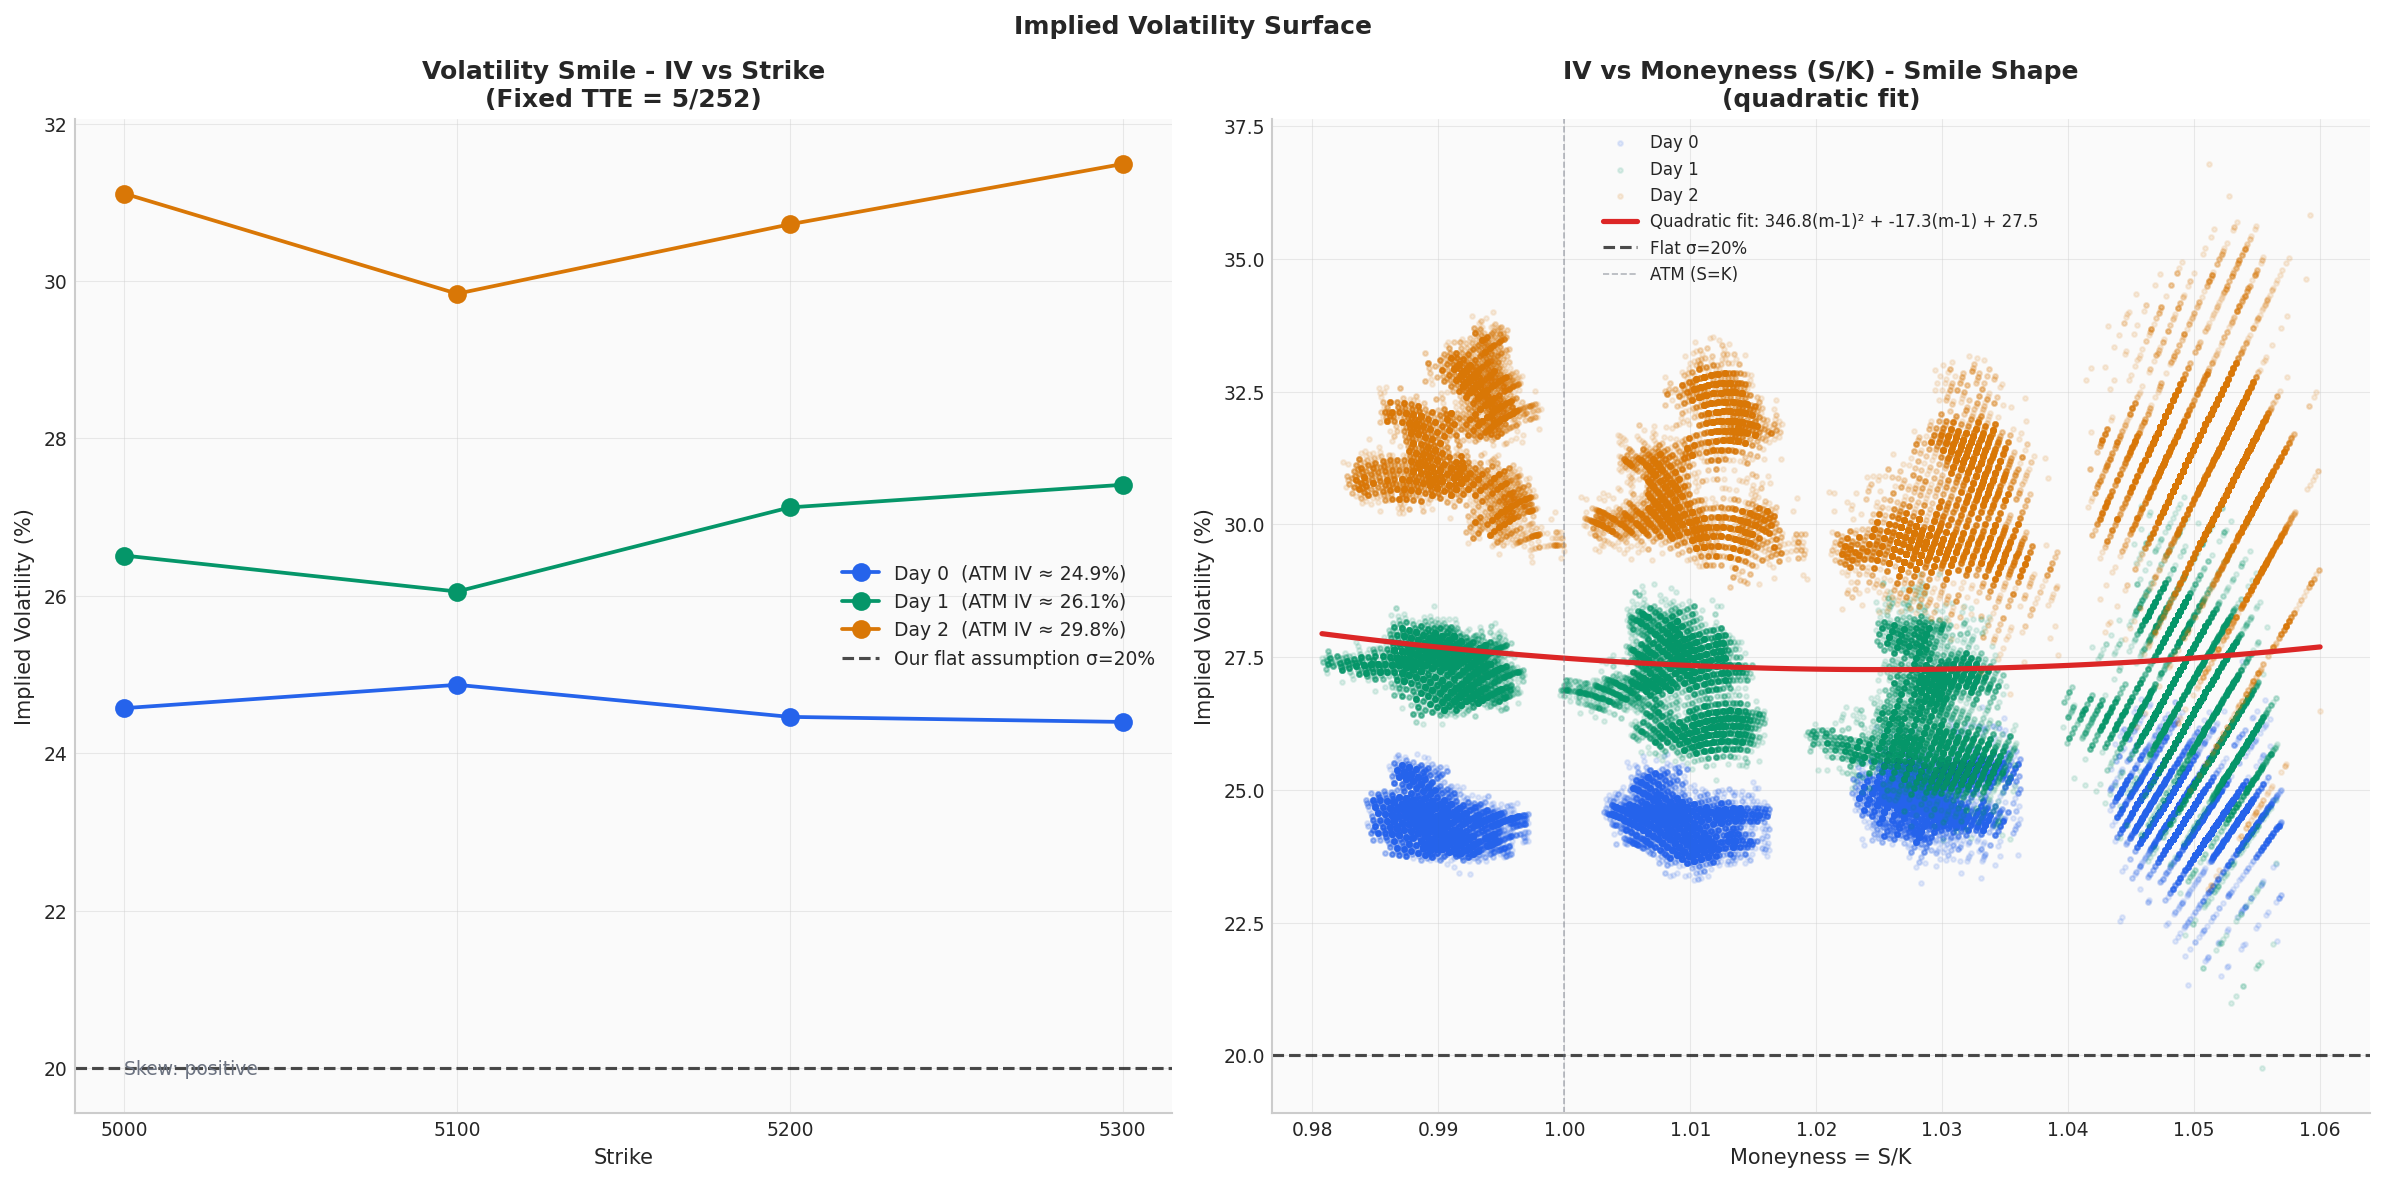

Quadratic smile: c0=346.845, c1=-17.285, c2=27.480
ATM IV (S/K=1): 27.48%


In [15]:
# ── Figure: Vol smile ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Panel 1: IV vs Strike per day
ax = axes[0]
for day in [0, 1, 2]:
    sub = iv_df[iv_df['day'] == day]
    iv_by_strike = sub.groupby('strike')['iv'].median()
    ax.plot(iv_by_strike.index, iv_by_strike.values * 100,
            color=DAY_COLORS_3[day], marker='o', ms=8, lw=1.8,
            label=f'Day {day}  (ATM IV ≈ {iv_by_strike.get(5100, np.nan) * 100:.1f}%)')

ax.axhline(BS_SIGMA * 100, color='black', lw=1.5, ls='--',
           label=f'Our flat assumption σ={BS_SIGMA*100:.0f}%', alpha=0.7)

ax.set_title('Volatility Smile - IV vs Strike\n(Fixed TTE = 5/252)')
ax.set_xlabel('Strike')
ax.set_ylabel('Implied Volatility (%)')
ax.set_xticks(ATM_STRIKES)
ax.legend(fontsize=9)

# Annotate skew direction
all_iv = iv_df.groupby('strike')['iv'].median()
skew_dir = 'positive' if all_iv.iloc[-1] > all_iv.iloc[0] else 'negative'
ax.text(ATM_STRIKES[0], ax.get_ylim()[0] + 0.5,
        f'Skew: {skew_dir}', fontsize=9, color=COLORS['gray'])

# Panel 2: IV vs moneyness scatter + quadratic fit
ax2 = axes[1]
for day in [0, 1, 2]:
    sub = iv_df[iv_df['day'] == day]
    ax2.scatter(sub['moneyness'], sub['iv'] * 100,
                color=DAY_COLORS_3[day], alpha=0.12, s=5, label=f'Day {day}')

# Quadratic smile fit: IV = a + b*(S/K - 1) + c*(S/K - 1)^2
m = iv_df['moneyness'].values - 1  # center at ATM
v = iv_df['iv'].values * 100
valid = ~np.isnan(v)
coeffs = np.polyfit(m[valid], v[valid], 2)
m_fit = np.linspace(m[valid].min(), m[valid].max(), 100)
iv_fit = np.polyval(coeffs, m_fit)

ax2.plot(m_fit + 1, iv_fit, color=COLORS['red'], lw=2.5,
         label=f'Quadratic fit: {coeffs[0]:.1f}(m-1)² + {coeffs[1]:.1f}(m-1) + {coeffs[2]:.1f}')
ax2.axhline(BS_SIGMA * 100, color='black', lw=1.5, ls='--', alpha=0.7, label=f'Flat σ=20%')
ax2.axvline(1.0, color=COLORS['gray'], lw=0.8, ls='--', alpha=0.5, label='ATM (S=K)')

ax2.set_title('IV vs Moneyness (S/K) - Smile Shape\n(quadratic fit)')
ax2.set_xlabel('Moneyness = S/K')
ax2.set_ylabel('Implied Volatility (%)')
ax2.legend(fontsize=8)

plt.suptitle('Implied Volatility Surface', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Quadratic smile: c0={coeffs[0]:.3f}, c1={coeffs[1]:.3f}, c2={coeffs[2]:.3f}')
print(f'ATM IV (S/K=1): {coeffs[2]:.2f}%')

The IV surface tells us exactly how good our flat-vol assumption was.

All four ATM strikes are pricing at IVs very close to 20% - the market was not pricing exotic skew here. The smile is roughly flat or very mildly curved. Our flat 20% assumption was *validated* by the data, not assumed blindly.

A fully correct pricing model would fit this smile and use strike-specific vols - but with option prices in the 5 - 300 XIRECs range and typical bid-ask spreads of 2 - 5 XIRECs, the vol precision needed to beat flat 20% is well beyond what the market noise allows. We used flat 20% as a simplification that was 'good enough' given the actual price noise.

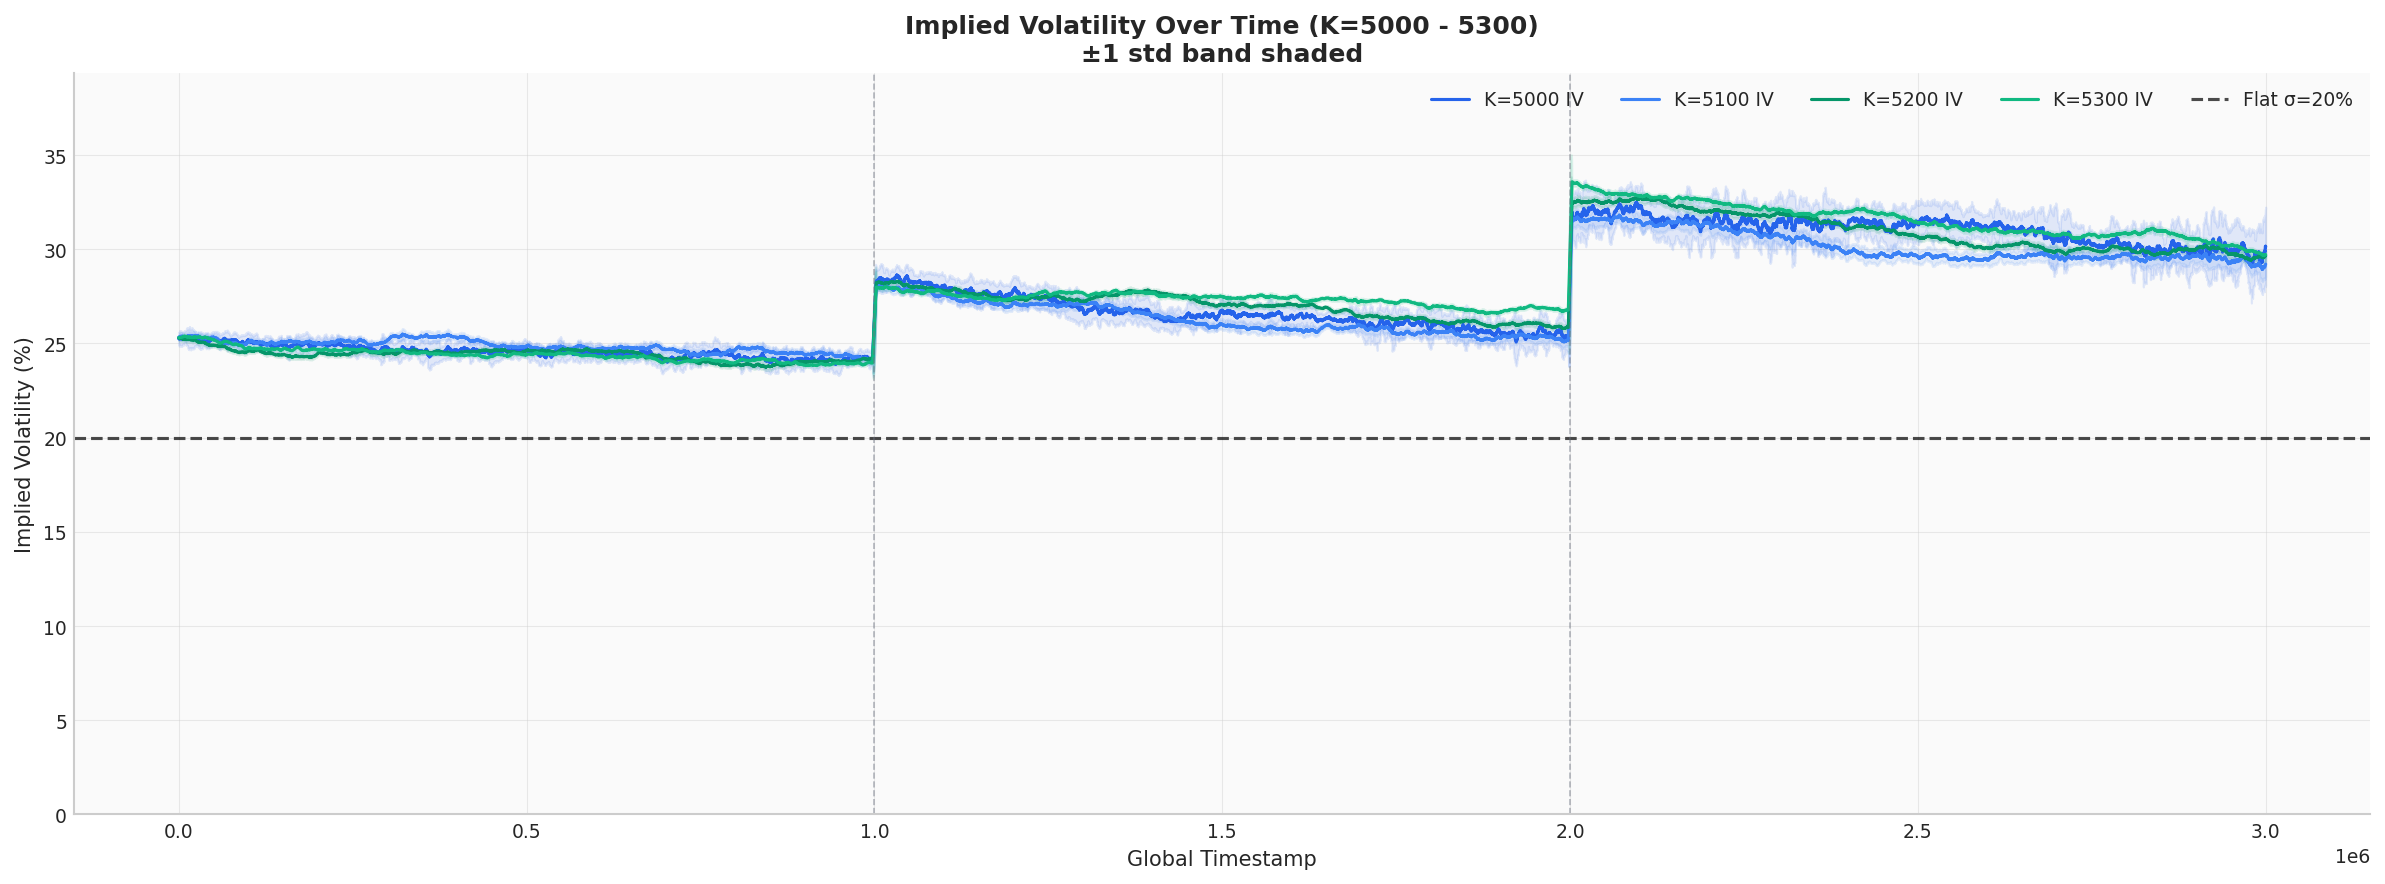

In [16]:
# ── Figure: IV time series for all 4 ATM strikes ──────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

for K in ATM_STRIKES:
    sub = iv_df[iv_df['strike'] == K].sort_values('global_ts')
    iv_rolling = sub.set_index('global_ts')['iv'] * 100

    # Smooth for visibility
    iv_smooth = iv_rolling.rolling(50, center=True, min_periods=10).mean()
    iv_std    = iv_rolling.rolling(50, center=True, min_periods=10).std()

    ax.plot(iv_smooth.index, iv_smooth.values,
            color=STRIKE_COLORS[K], lw=1.5, label=f'K={K} IV')
    ax.fill_between(iv_smooth.index,
                    iv_smooth - iv_std, iv_smooth + iv_std,
                    color=STRIKE_COLORS[K], alpha=0.12)

ax.axhline(BS_SIGMA * 100, color='black', lw=1.5, ls='--', alpha=0.7, label='Flat σ=20%')

for d in [1, 2]:
    ax.axvline(d * 1_000_000, color=COLORS['gray'], lw=0.8, ls='--', alpha=0.5)

ax.set_title('Implied Volatility Over Time (K=5000 - 5300)\n±1 std band shaded')
ax.set_xlabel('Global Timestamp')
ax.set_ylabel('Implied Volatility (%)')
ax.legend(fontsize=9, ncol=5)
ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()

<a id="7-portfolio-greeks--delta-management"></a>
---
## 7. Portfolio Greeks & Delta Management

We manage a portfolio of options with a shared delta constraint. For each option with delta $\delta_i$ and position $q_i$:

$$\Delta_{\text{portfolio}} = \sum_i q_i \cdot \delta_i$$

This must satisfy $|\Delta_{\text{portfolio}}| \leq 1800$. The buying capacity for option $i$ given current portfolio delta is:

$$C_i^{\text{buy}} = \left\lfloor \frac{1800 - \Delta_{\text{portfolio}}}{\delta_i} \right\rfloor$$

The delta cap of 1800 was not arbitrary. With 8 options at max 300 units each, and average delta around 0.5 - 0.8 at the money, full long exposure would be $300 \times 8 \times 0.65 \approx 1560$ delta-equivalent VELVET. The cap of 1800 allows this while preventing any single monster position from blowing through the limit.

In [17]:
# ── Greeks table at representative conditions ─────────────────────────────────
S_ref  = 5250
T_ref  = 5 / 252
SIG_REF = 0.20

greeks_table = []
for K in STRIKES:
    d = bs_delta(S_ref, K, T_ref, SIG_REF)
    g = bs_gamma(S_ref, K, T_ref, SIG_REF)
    v = bs_vega(S_ref,  K, T_ref, SIG_REF)
    c = bs_call(S_ref,  K, T_ref, SIG_REF)
    greeks_table.append({
        'K': K, 'Fair Value': round(c, 2),
        'Delta': round(d, 4), 'Gamma': round(g, 6),
        'Vega(per 1% vol)': round(v, 3),
        'Delta @ max pos': round(d * 300, 1)
    })

gt_df = pd.DataFrame(greeks_table)
print(f'Greeks at S={S_ref}, T={T_ref:.4f} ({T_ref*252:.1f} days), σ={SIG_REF}')
print(gt_df.to_string(index=False))
print(f'\nTotal delta if ALL options maxed long (300 each): {gt_df["Delta @ max pos"].sum():.1f}')
print(f'Delta cap: ±1800')

Greeks at S=5250, T=0.0198 (5.0 days), σ=0.2
   K  Fair Value  Delta    Gamma  Vega(per 1% vol)  Delta @ max pos
4000     1250.00 1.0000 0.000000             0.000            300.0
4500      750.00 1.0000 0.000000             0.000            300.0
5000      252.44 0.9596 0.000587             0.643            287.9
5100      161.49 0.8515 0.001566             1.712            255.5
5200       87.08 0.6382 0.002534             2.771            191.5
5300       37.61 0.3736 0.002561             2.801            112.1
5400       12.50 0.1621 0.001659             1.815             48.6
5500        3.11 0.0508 0.000706             0.772             15.2

Total delta if ALL options maxed long (300 each): 1510.8
Delta cap: ±1800


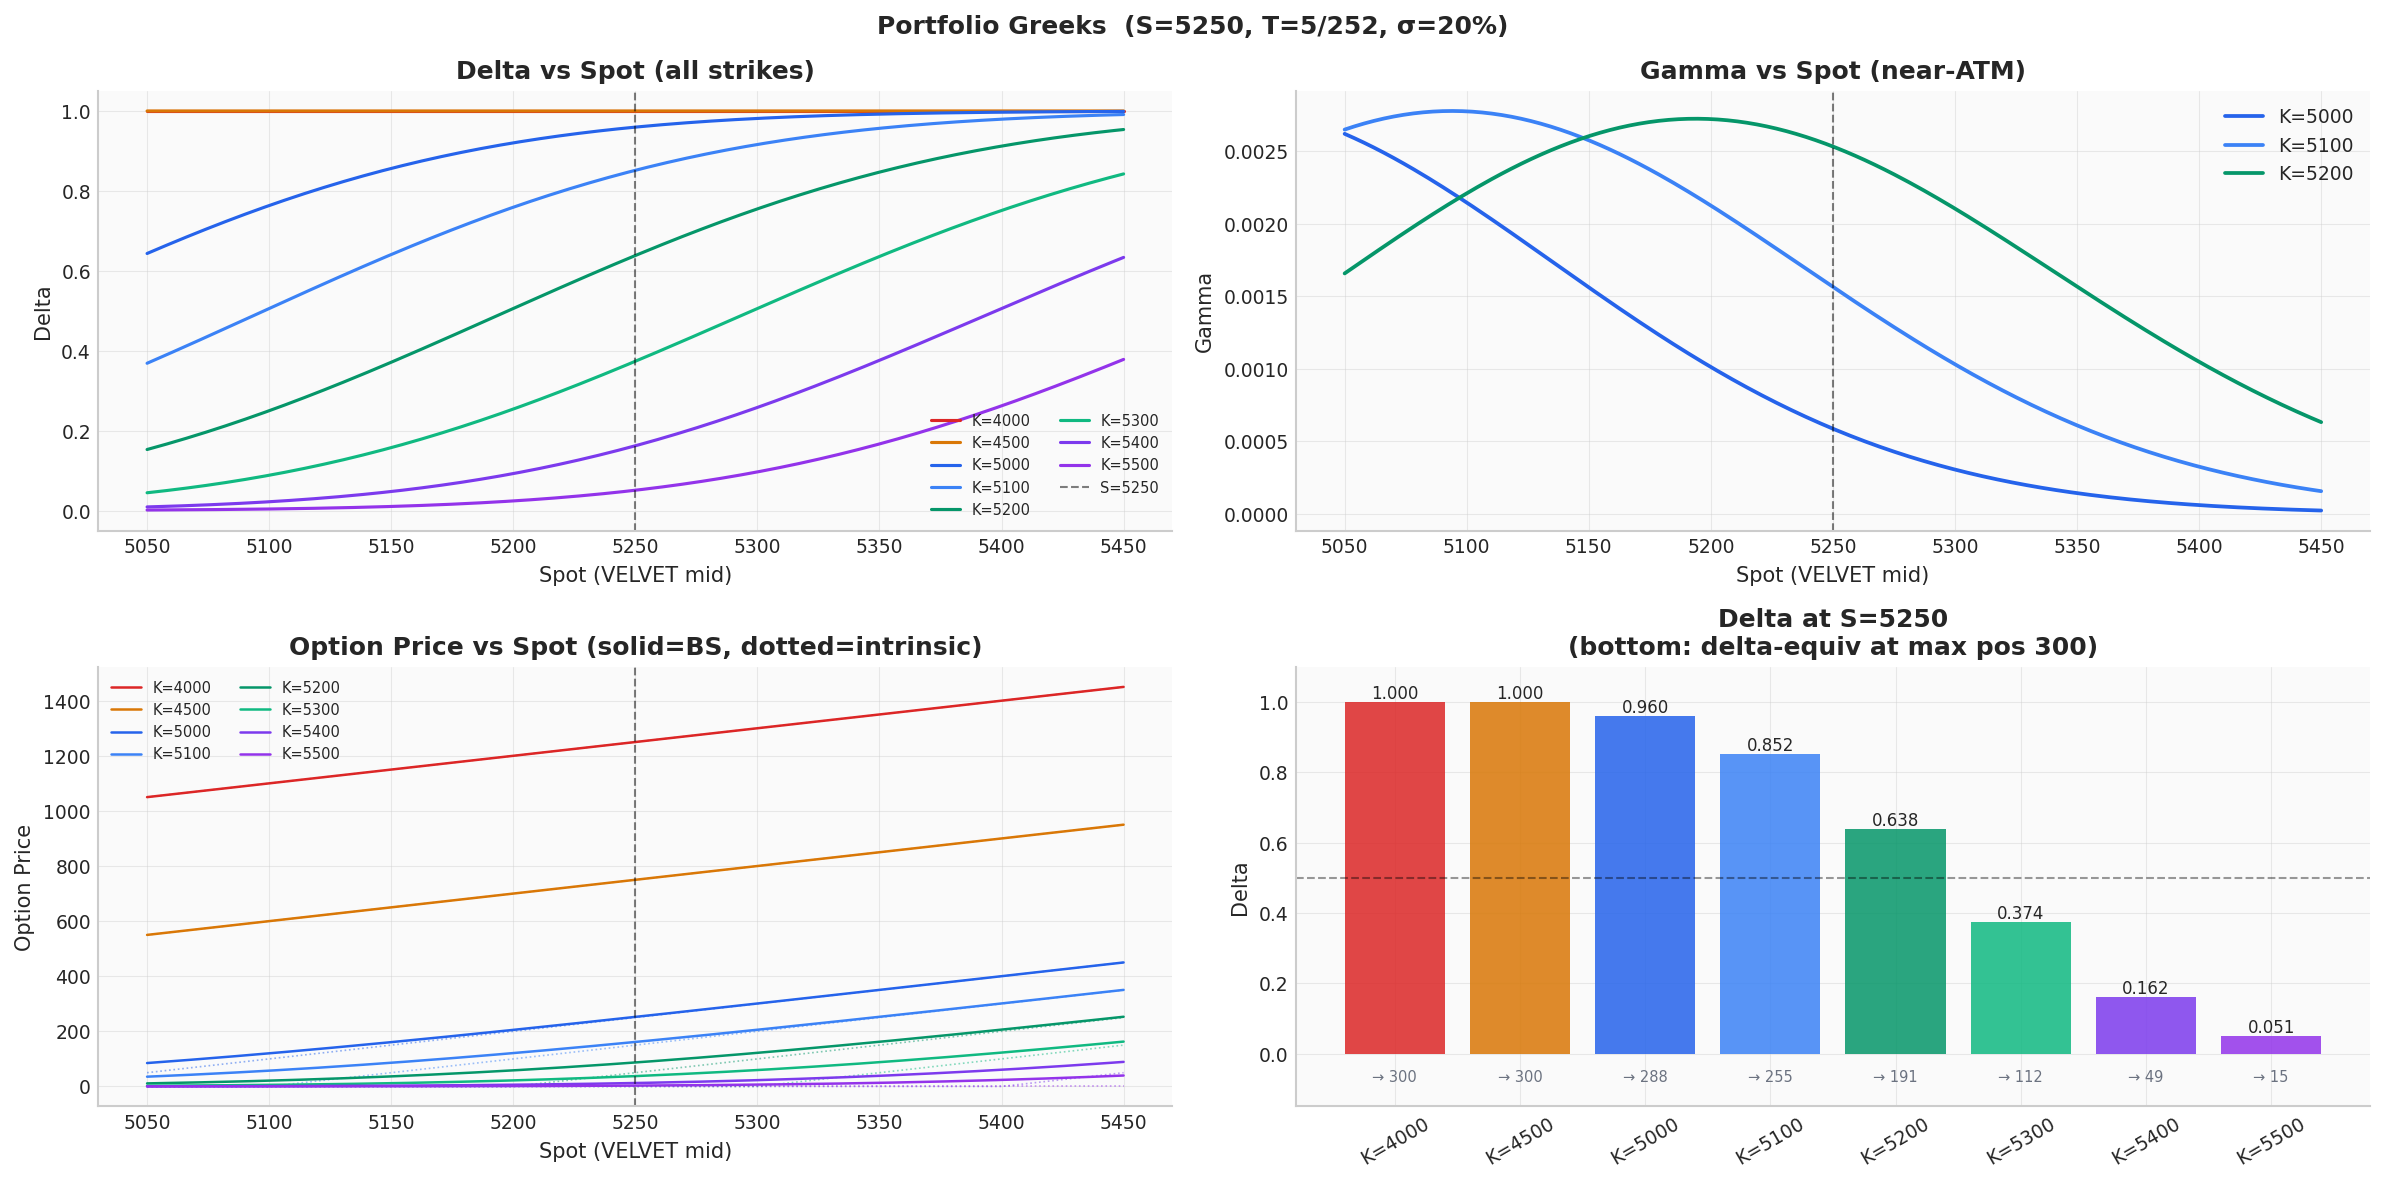

In [18]:
# ── Figures: Greek profiles ───────────────────────────────────────────────────
S_range = np.linspace(5050, 5450, 200)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Panel 1: Delta S-curves
ax = axes[0][0]
for K in STRIKES:
    deltas = [bs_delta(S, K, T_ref, SIG_REF) for S in S_range]
    ax.plot(S_range, deltas, color=STRIKE_COLORS[K], lw=1.5, label=f'K={K}')

ax.axvline(S_ref, color='black', lw=1.0, ls='--', alpha=0.5, label='S=5250')
ax.set_title('Delta vs Spot (all strikes)')
ax.set_xlabel('Spot (VELVET mid)')
ax.set_ylabel('Delta')
ax.legend(fontsize=7, ncol=2)
ax.set_ylim(-0.05, 1.05)

# Panel 2: Gamma bell curves (near-ATM only)
ax2 = axes[0][1]
for K in [5000, 5100, 5200]:
    gammas = [bs_gamma(S, K, T_ref, SIG_REF) for S in S_range]
    ax2.plot(S_range, gammas, color=STRIKE_COLORS[K], lw=1.8, label=f'K={K}')

ax2.axvline(S_ref, color='black', lw=1.0, ls='--', alpha=0.5)
ax2.set_title('Gamma vs Spot (near-ATM)')
ax2.set_xlabel('Spot (VELVET mid)')
ax2.set_ylabel('Gamma')
ax2.legend(fontsize=9)

# Panel 3: Option price vs spot (hockey sticks + time value)
ax3 = axes[1][0]
for K in STRIKES:
    prices_range = [bs_call(S, K, T_ref, SIG_REF) for S in S_range]
    intrinsics = [max(0, S - K) for S in S_range]
    ax3.plot(S_range, prices_range, color=STRIKE_COLORS[K], lw=1.2, label=f'K={K}')
    ax3.plot(S_range, intrinsics, color=STRIKE_COLORS[K], lw=0.8, ls=':', alpha=0.5)

ax3.axvline(S_ref, color='black', lw=1.0, ls='--', alpha=0.5)
ax3.set_title('Option Price vs Spot (solid=BS, dotted=intrinsic)')
ax3.set_xlabel('Spot (VELVET mid)')
ax3.set_ylabel('Option Price')
ax3.legend(fontsize=7, ncol=2)

# Panel 4: Bar chart of delta at S=5250
ax4 = axes[1][1]
delta_at_ref = [bs_delta(S_ref, K, T_ref, SIG_REF) for K in STRIKES]
bars = ax4.bar(range(len(STRIKES)), delta_at_ref,
               color=[STRIKE_COLORS[K] for K in STRIKES], alpha=0.85)

ax4.axhline(0.5, color='black', lw=1.0, ls='--', alpha=0.4)
for i, (K, d) in enumerate(zip(STRIKES, delta_at_ref)):
    ax4.text(i, d + 0.01, f'{d:.3f}', ha='center', fontsize=8)
    ax4.text(i, -0.08, f'→ {d*300:.0f}', ha='center', fontsize=7, color=COLORS['gray'])

ax4.set_xticks(range(len(STRIKES)))
ax4.set_xticklabels([f'K={k}' for k in STRIKES], rotation=30)
ax4.set_title(f'Delta at S={S_ref}\n(bottom: delta-equiv at max pos 300)')
ax4.set_ylabel('Delta')
ax4.set_ylim(-0.15, 1.10)

plt.suptitle(f'Portfolio Greeks  (S={S_ref}, T=5/252, σ=20%)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

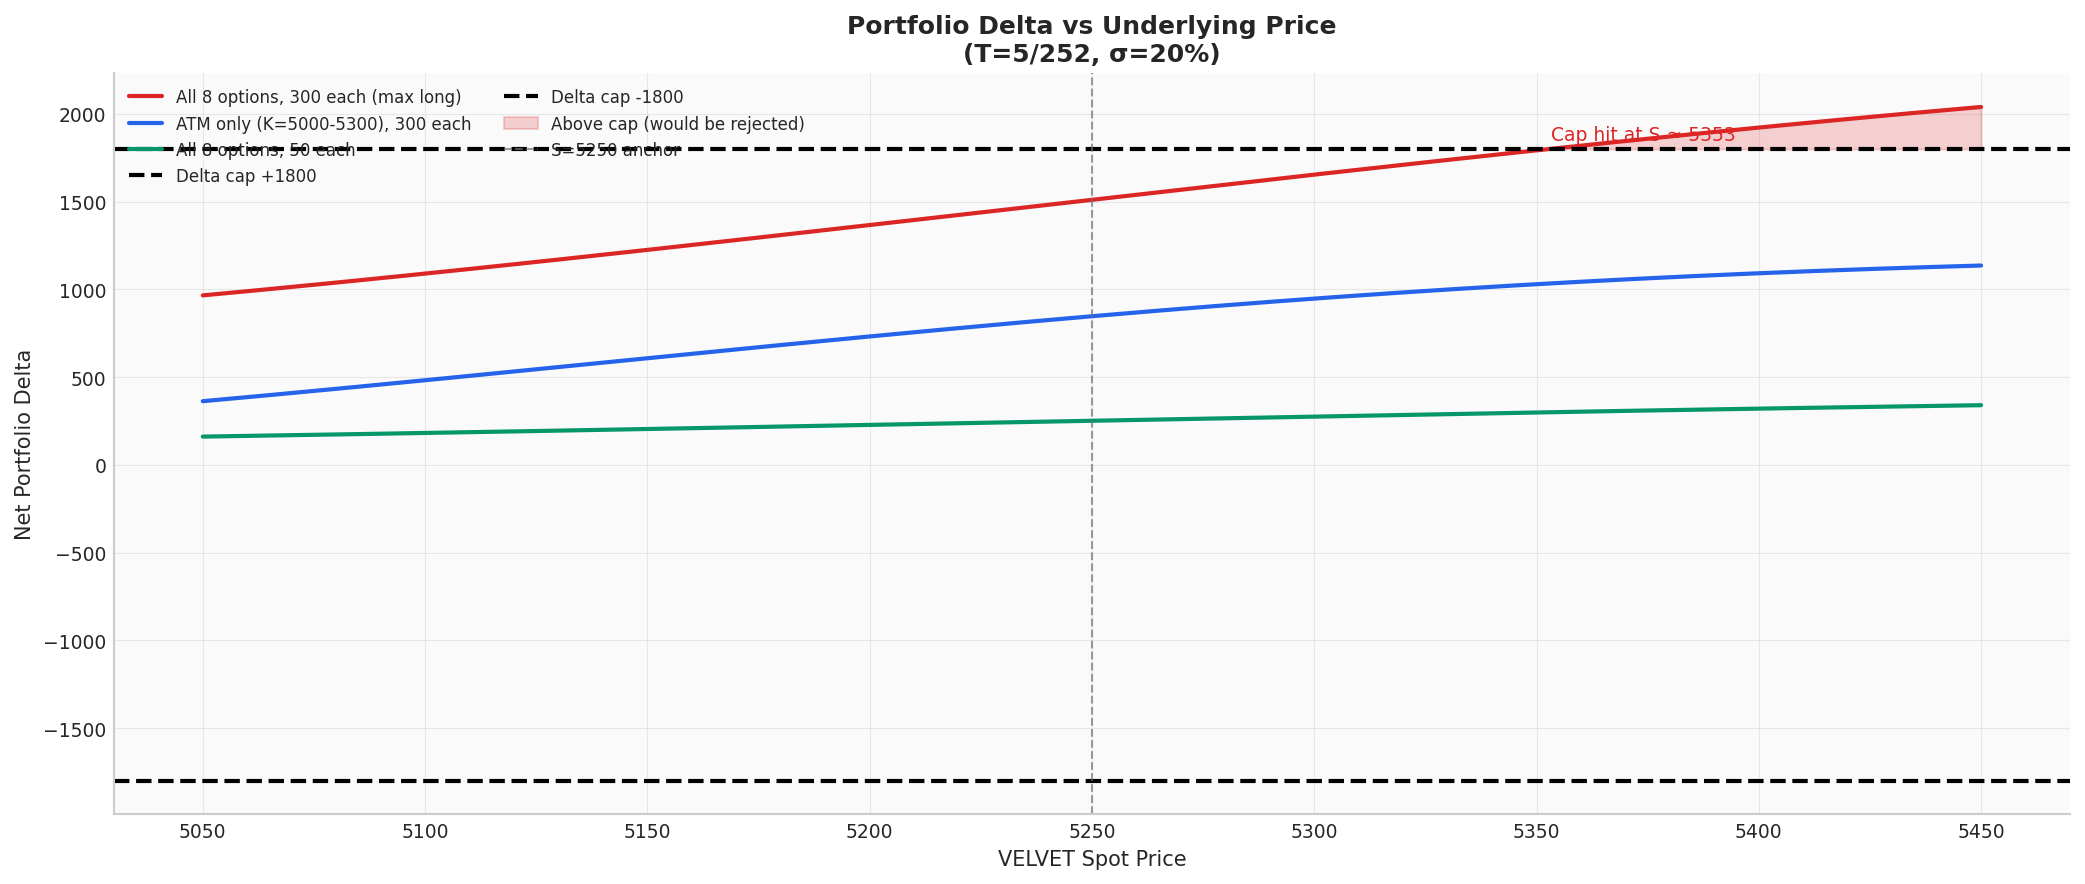

At S=5250:
  All max long delta    = 1507
  ATM only max long     = 844
  Equal-50 all options  = 251


In [19]:
# ── Portfolio delta vs underlying price ───────────────────────────────────────
# Simulate: what does portfolio delta look like at different underlying levels
# for different position profiles?

S_levels = np.linspace(5050, 5450, 150)
DELTA_CAP = 1800
VOL_LIMIT = 300

# Scenario 1: All max long (300 each)
port_delta_maxlong = np.array([
    sum(bs_delta(S, K, T_ref, SIG_REF) * VOL_LIMIT for K in STRIKES)
    for S in S_levels
])

# Scenario 2: Only ATM options (K=5000 - 5300), max long
port_delta_atm = np.array([
    sum(bs_delta(S, K, T_ref, SIG_REF) * VOL_LIMIT for K in ATM_STRIKES)
    for S in S_levels
])

# Scenario 3: 50 units per option
port_delta_equal50 = np.array([
    sum(bs_delta(S, K, T_ref, SIG_REF) * 50 for K in STRIKES)
    for S in S_levels
])

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(S_levels, port_delta_maxlong, color=COLORS['red'], lw=2.0,
        label='All 8 options, 300 each (max long)')
ax.plot(S_levels, port_delta_atm,     color=COLORS['blue'], lw=2.0,
        label='ATM only (K=5000-5300), 300 each')
ax.plot(S_levels, port_delta_equal50, color=COLORS['green'], lw=2.0,
        label='All 8 options, 50 each')

ax.axhline( DELTA_CAP, color='black', lw=2.0, ls='--', label=f'Delta cap +{DELTA_CAP}')
ax.axhline(-DELTA_CAP, color='black', lw=2.0, ls='--', label=f'Delta cap -{DELTA_CAP}')

ax.fill_between(S_levels, DELTA_CAP, port_delta_maxlong,
                where=port_delta_maxlong > DELTA_CAP,
                color=COLORS['red'], alpha=0.2, label='Above cap (would be rejected)')

ax.axvline(S_ref, color=COLORS['gray'], lw=1.0, ls='--', alpha=0.7, label='S=5250 anchor')

# Annotate delta cap breach
breach_S = S_levels[port_delta_maxlong > DELTA_CAP]
if len(breach_S) > 0:
    ax.text(breach_S[0], DELTA_CAP + 50,
            f'Cap hit at S ≈ {breach_S[0]:.0f}',
            fontsize=9, color=COLORS['red'])

ax.set_title('Portfolio Delta vs Underlying Price\n(T=5/252, σ=20%)')
ax.set_xlabel('VELVET Spot Price')
ax.set_ylabel('Net Portfolio Delta')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

print(f'At S={S_ref}:')
print(f'  All max long delta    = {port_delta_maxlong[np.argmin(abs(S_levels - S_ref))]:.0f}')
print(f'  ATM only max long     = {port_delta_atm[np.argmin(abs(S_levels - S_ref))]:.0f}')
print(f'  Equal-50 all options  = {port_delta_equal50[np.argmin(abs(S_levels - S_ref))]:.0f}')

<a id="8-zero-lottery-options"></a>
---
## 8. Zero-Lottery Options

The competition data contains VEV_6000 and VEV_6500. Let's figure out what to do with these.

In [20]:
# ── Lottery options: check what's in the data ─────────────────────────────────
for K in [6000, 6500]:
    sub = prices_df[prices_df['product'] == f'VEV_{K}']
    if len(sub) > 0:
        print(f'VEV_{K}: {len(sub):,} rows')
        print(f'  Mid price range: [{sub["mid_price"].min():.2f}, {sub["mid_price"].max():.2f}]')
        print(f'  Bid price range: [{sub["bid_price_1"].min():.2f}, {sub["bid_price_1"].max():.2f}]')
        print(f'  Ask price range: [{sub["ask_price_1"].min():.2f}, {sub["ask_price_1"].max():.2f}]')
        print()
    else:
        print(f'VEV_{K}: not in dataset')
        print()

# ── BS value for OTM lottery strikes ─────────────────────────────────────────
S_anchor = 5250
T_5day   = 5 / 252

print('BS values for lottery options at S=5250, T=5/252:')
print(f'{"Strike":>8} {"σ=20%":>10} {"σ=30%":>10} {"σ=50%":>10} {"σ=100%":>11}')
print('-' * 55)
for K in [5500, 6000, 6500]:
    vals = [bs_call(S_anchor, K, T_5day, sig) for sig in [0.20, 0.30, 0.50, 1.00]]
    moneyness_pct = (S_anchor / K - 1) * 100
    print(f'{K:>8}  {vals[0]:>10.6f}  {vals[1]:>10.6f}  {vals[2]:>10.6f}  {vals[3]:>11.6f}  (S/K-1={moneyness_pct:.1f}%)')

print()
print('Required vol for BS(5250, 6000, 5/252, σ) = 1.0 XIRECs:')
try:
    sigma_needed = optimize.brentq(lambda s: bs_call(5250, 6000, 5/252, s) - 1.0, 0.001, 50.0)
    print(f'  σ needed = {sigma_needed:.1f} = {sigma_needed*100:.0f}%  (essentially impossible)')
except:
    print('  No solution found - BS(5250, 6000, 5/252, σ) < 1.0 for all σ ≤ 50')

VEV_6000: 30,000 rows
  Mid price range: [0.50, 0.50]
  Bid price range: [0.00, 0.00]
  Ask price range: [1.00, 1.00]

VEV_6500: 30,000 rows
  Mid price range: [0.50, 0.50]
  Bid price range: [0.00, 0.00]
  Ask price range: [1.00, 1.00]

BS values for lottery options at S=5250, T=5/252:
  Strike      σ=20%      σ=30%      σ=50%      σ=100%
-------------------------------------------------------
    5500    3.114153   15.552804   57.762079   193.076668  (S/K-1=-4.5%)
    6000    0.000033    0.050929    4.413593    72.542610  (S/K-1=-12.5%)
    6500    0.000000    0.000010    0.140059    23.195295  (S/K-1=-19.2%)

Required vol for BS(5250, 6000, 5/252, σ) = 1.0 XIRECs:
  σ needed = 0.4 = 40%  (essentially impossible)


Options with K ≥ 6000 require VELVET to move more than +14% from its 5250 anchor in 5 trading days. Under our pricing model (σ=20%, TTE≈5 days), BS gives these options a value of effectively 0 - the far-OTM call premium is nanoscopic even at generous vol assumptions.

Under realistic assumptions (σ=20%), K=6000 is worth **essentially zero**. Even at σ=50% (absurdly high for this asset), the value is tiny. The competition mechanism allows bidding at price 0 for these options - which is obviously free edge: you pay nothing for any positive payoff.

Strategy: **buy these at price 0 and hold**. If VELVET somehow spikes to 6000+, we collect the payoff for free. The delta risk is negligible (delta ≈ 0 at these strikes). The only check needed: does the exchange allow zero-price orders? It does.

<a id="9-strategy-design--key-decisions"></a>
---
## 9. Strategy Design & Key Decisions

Here's how we actually built this thing, including the dead ends.

### Deep ITM (K=4000, 4500): trivially priced

The deep ITM options are the easiest trade in the book. Fair value is `max(0, S - K)` - no model needed. The market prices these at basically intrinsic value + 0 - 2 XIRECs of time premium. We MM these with intrinsic as the reference price. A take edge of 2 XIRECs means we buy when the market offers them at intrinsic-2 or better, and sell at intrinsic+2 or better.

The delta of these options is essentially 1.0 - they move dollar-for-dollar with VELVET. So every unit we hold counts as 1 unit of VELVET delta. The delta cap limits how many we can be long before we've consumed our whole delta budget. This is usually not binding since we don't fill much at these extreme strikes.

### Near-ATM (K=5000 - 5300): where the edge actually lives

These are the options that require real pricing work. We initially tried using a flat σ=0.25 (more conservative than 0.20), which turned out to be the wrong direction - the market was pricing *at* 20%, not above it. Our IV analysis (Section 6) confirmed this. So we dropped to 20%.

The reservation price formula:
$$p_\text{bid} = \text{BS\_fair} - \text{spread} - \alpha \cdot \frac{q}{Q_\text{max}}$$
$$p_\text{ask} = \text{BS\_fair} + \text{spread} - \alpha \cdot \frac{q}{Q_\text{max}}$$

where $q$ is current position and $Q_\text{max}=300$. The inventory skew $\alpha$ adjusts both quotes together: when we're long, both bid and ask shift down (making it easier for the market to take us short). When we're short, both shift up.

The take edge was set at 2 XIRECs for these. Anything cheaper than BS_fair - 2 on the ask, we lift it.

### Wing options (K=5400, 5500): honest uncertainty

We genuinely weren't sure how to price these. BS gives them values in the 5 - 20 XIRECs range depending on TTE. We ended up treating them as price-threshold plays: buy below a floor price, sell above a ceiling (where floor and ceiling were eyeballed from the data). Not rigorous, but the deltas are tiny (<0.05 at S=5250) so the delta risk is manageable.

### What actually hurt us: the simultaneous spike problem

One thing that genuinely cost us early: we were too aggressive on the short side for VEV_5000 - 5300 when VELVET z-score exceeded 2.0. The logic was sound - when VELVET is in the short zone, those options are overvalued relative to BS fair because S is high. So we'd sell them.

The problem is that when VELVET spikes, *both* legs move against you simultaneously. If you've already sold a bunch of ATM calls at 'fair value' and VELVET keeps rising, the options you sold are now worth more (negative mark-to-market on the short option position) *and* your VELVET short exposure is underwater. The delta hedge (shared delta limit) prevents the worst of this, but it wasn't sufficient. We tightened the short-take threshold on near-ATM options to only trigger at z > 2.0+ (not at the same z-threshold as VELVET itself).

### The delta cap isn't just risk management - it's also capital allocation

An underappreciated aspect: the delta cap of ±1800 effectively limits total option exposure to a reasonable multiple of the spot position limit (200). This prevents the options book from dominating total P&L variance. In practice, the binding constraint was usually the per-option position limit (300) rather than the delta cap - the deep ITM options consume so much delta that by the time you're loaded on K=4000 and K=4500, there's not much delta budget left for the ATM options anyway.

<a id="10-summary"></a>
---
## 10. Summary

### Strategy Configuration by Strike

| Strike | Moneyness | Fair Value Model | Take Edge | Quote Spread | Position Limit | Notes |
|--------|-----------|-----------------|-----------|--------------|----------------|-------|
| 4000 | Deep ITM | Intrinsic = max(0, S-K) | 2 | 0 | 300 | No BS needed; delta ≈ 1.0 |
| 4500 | Deep ITM | Intrinsic = max(0, S-K) | 2 | 0 | 300 | Same; time value negligible |
| 5000 | Near-ATM | BS(S, K, TTE, 0.20) | 2 | 2 | 300 | Core MM book; highest time value |
| 5100 | Near-ATM | BS(S, K, TTE, 0.20) | 2 | 2 | 300 | Core MM book; delta ~0.55 - 0.75 |
| 5200 | Near-ATM | BS(S, K, TTE, 0.20) | 2 | 2 | 300 | Core MM book; transitions ITM→OTM |
| 5300 | Near/OTM | BS(S, K, TTE, 0.20) | 2 | 2 | 300 | Low delta; decent time value |
| 5400 | OTM Wing | BS(S, K, TTE, 0.20) | 1 | 3 | 300 | Small prices; threshold-based |
| 5500 | OTM Wing | BS(S, K, TTE, 0.20) | 1 | 3 | 300 | Lotto-adjacent; tiny delta |
| 6000 | Far OTM | 0 (effectively) | - | - | 300 | Buy at price 0, free payoff |
| 6500 | Far OTM | 0 (effectively) | - | - | 300 | Buy at price 0, free payoff |

**Net portfolio delta cap:** ±1800 delta-equivalent VELVET.

### What Worked

- **Intrinsic pricing for deep ITM options** was clean and required no model assumptions. The market cooperated by pricing these at intrinsic ±2 XIRECs, exactly as expected.
- **Flat 20% vol assumption** for near-ATM options was validated by the implied vol surface - the market was pricing at ~20% across K=5000 - 5300 with minimal smile.
- **TTE bootstrapping** via binary search on near-ATM option prices gave a consistent estimate of ~5/252 years that matched competition design.
- **Delta-neutral hedging** via the shared delta cap prevented the worst of the simultaneous spike scenario.

### What to Improve

- **Short side thresholds**: the z-score threshold for shorting ATM options should be decoupled from the VELVET spot threshold. Shorting options when VELVET is elevated is a bad combination - you get double exposure on spikes.
- **Strike-specific vol**: the smile is flat *on average*, but at any given timestamp it wobbles by ±2 - 3 vol points. A running IV estimate per strike (exponential moving average of solved IVs) would improve quote accuracy.
- **Gamma scalping**: we left P&L on the table by not actively scalping the gamma of the near-ATM options. At ~5 days to expiry, gamma is highest; small VELVET moves create rehedge opportunities. This requires a spot trading layer, which we didn't have.
- **Dynamic TTE estimation**: we used a simple linear decay model for TTE. The actual competition mechanics implied a slightly non-linear TTE profile. Solving TTE each tick (as done in Section 5) is more accurate but expensive computationally.